# Visualización de datos con ggplot2

## Objetivo

El objetivo de esta actividad es que los alumnos puedan tener una comprensión fundamental de la visualización de datos utilizando **ggplot2 en R**.  

Al finalizar, serán capaces de:

- Crear gráficos básicos e intermedios.
- Personalizar estéticas y temas.
- Emplear técnicas de visualización para explorar y comunicar datos de manera efectiva.

---

## Instrucciones

Los alumnos deberán descargar las siguientes bases de datos:

- `Accidentes_ags_2021.csv`
- `Accidentes_ags_2022.csv`

Estos archivos están disponibles en:

- http://u.pc.cd/tbWctalK  

Contienen información sobre accidentes de tránsito ocurridos en el Estado de Aguascalientes durante los años 2021 y 2022.

Los archivos fueron descargados de la página del INEGI y están disponibles (para todo México) en:

- Subsistema de Información Económica  
- Registros Administrativos - Estadísticas  
- https://www.inegi.org.mx/datosabiertos/

Para facilitar la interpretación de los datos, es esencial consultar también el diccionario de datos:

- `fd_bd_atus_georreferenciación.xlsx`

Es importante revisar este documento para comprender el significado de cada columna en las bases de datos.

Una vez descargadas las bases de datos, los alumnos deberán:

1. Abrir los archivos CSV.
2. Crear gráficos utilizando **ggplot2**.
3. Visualizar la información que consideren más relevante.

Se recomienda:

- Ser creativos en la manipulación y procesamiento de los datos.
- Asegurar que los gráficos sean de alta calidad.
- Proporcionar información útil a partir de los datos.

Pueden apoyarse en las siguientes preguntas:

1. ¿Puedes descubrir patrones o tendencias interesantes en los datos?
2. ¿Puedes representar los datos de una manera que cuente una historia o revele algo sorprendente sobre los accidentes de tránsito en Aguascalientes para los años 2021 y 2022?

Deberán elaborar un documento en formato **PDF** que incluya:

- Contexto de la información manejada.
- Detalles sobre las bases de datos utilizadas.
- Gráficos generados.
- Interpretación y análisis de cada gráfico.
- Conclusiones generales de la actividad.
- Recomendaciones sobre acciones que puedan ser útiles para reducir accidentes en la población.


---
# Configuración Inicial
## Instalación y carga de paquetes necesarios

In [ ]:
# Instalar paquetes necesarios (ejecutar solo la primera vez)
install.packages(
  c("ggplot2", "dplyr", "tidyr", "readr", "scales", "forcats", "gridExtra")
)

In [4]:
# Cargar librerías
library(ggplot2)
library(dplyr)
library(tidyr)
library(readr)
library(scales)
library(forcats)
library(gridExtra)

# Configurar tema global
theme_set(theme_minimal(base_size = 12))

# Crear función de tema personalizado
theme_accidentes <- function() {
  theme_minimal(base_size = 11) +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold", size = 13),
      plot.subtitle = element_text(hjust = 0.5, size = 10),
      axis.title = element_text(face = "bold"),
      legend.position = "right",
      panel.grid.minor = element_blank(),
      panel.grid.major = element_line(color = "gray90"),
      panel.background = element_rect(fill = "white", color = NA),
      plot.background = element_rect(fill = "white", color = NA)
    )
}

cat("✓ Librerías cargadas exitosamente\n")

✓ Librerías cargadas exitosamente


## Carga y preparación de datos

In [5]:
# Cargar datos desde la carpeta 'datos'
datos_2021 <- read_csv(
  "datos/Accidentes_ags_2021.csv",
  locale = locale(encoding = "UTF-8")
)
datos_2022 <- read_csv(
  "datos/Accidentes_ags_2022.csv",
  locale = locale(encoding = "UTF-8")
)

# Agregar columna de año
datos_2021$ANIO <- 2021
datos_2022$ANIO <- 2022

# Combinar ambos años
datos_completos <- bind_rows(datos_2021, datos_2022)

# Mostrar información básica
cat("============================================\n")
cat("    INFORMACIÓN DE LOS DATOS CARGADOS      \n")
cat("============================================\n")
cat(sprintf("Registros 2021: %s\n", format(nrow(datos_2021), big.mark = ",")))
cat(sprintf("Registros 2022: %s\n", format(nrow(datos_2022), big.mark = ",")))
cat(sprintf(
  "Total accidentes: %s\n",
  format(nrow(datos_completos), big.mark = ",")
))
cat(sprintf("Variables: %d\n", ncol(datos_completos)))
cat("============================================\n")

Rows: 3198 Columns: 49
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): ID, CALLE1, CALLE2, CARRETERA
dbl (45): EDO, MES, ANIO, MPIO, HORA, MINUTOS, DIA, DIASEMANA, URBANA, SUBUR...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3313 Columns: 50
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): ID, CALLE1, CALLE2, CARRETERA
dbl (46): EDO, MES, ANIO, MPIO, HORA, MINUTOS, DIA, DIASEMANA, URBANA, SUBUR...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


    INFORMACIÓN DE LOS DATOS CARGADOS      
Registros 2021: 3,198
Registros 2022: 3,313
Total accidentes: 6,511
Variables: 50


In [6]:
# Ver estructura de los datos
glimpse(datos_completos)

Rows: 6,511
Columns: 50
$ ID         <chr> "1009255-112-190821532", "1009255-112-190821538", "1009255-…
$ EDO        <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ MES        <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ ANIO       <dbl> 2021, 2021, 2021, 2021, 2021, 2021, 2021, 2021, 2021, 2021,…
$ MPIO       <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ HORA       <dbl> 0, 0, 0, 0, 0, 1, 2, 4, 7, 8, 9, 11, 11, 15, 17, 20, 21, 1,…
$ MINUTOS    <dbl> 0, 0, 0, 0, 50, 24, 30, 20, 10, 25, 5, 10, 45, 40, 55, 30, …
$ DIA        <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,…
$ DIASEMANA  <dbl> 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6,…
$ URBANA     <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ SUBURBANA  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ TIPACCID   <dbl> 1, 1, 2, 4, 2, 4, 4, 1, 1, 2, 4, 1, 1, 2, 10, 1, 10, 4, 2, …
$ AUTOMOVIL  <db

In [8]:
# Crear etiquetas descriptivas para todas las variables
datos_completos <- datos_completos %>%
  mutate(
    # Mes
    mes_nombre = factor(MES, levels = 1:12,
                        labels = c("Enero", "Febrero", "Marzo",
                                   "Abril", "Mayo", "Junio",
                                   "Julio", "Agosto", "Septiembre",
                                   "Octubre", "Noviembre", "Diciembre")),

    # Día de la semana
    dia_semana_nombre = factor(DIASEMANA, levels = 1:7,
                               labels = c("Lunes", "Martes",
                                          "Miércoles", "Jueves",
                                          "Viernes", "Sábado", "Domingo")),

    # Clasificación del accidente
    clase_nombre = factor(CLASE, levels = 1:3,
                          labels = c("Fatal", "No fatal", "Sólo daños")),

    # Tipo de accidente
    tipo_accidente_nombre = factor(TIPACCID, levels = 1:12,
                                   labels = c("Colisión vehículo",
                                              "Atropellamiento",
                                              "Colisión animal",
                                              "Colisión objeto fijo",
                                              "Volcadura", "Caída pasajero",
                                              "Salida del camino",
                                              "Incendio",
                                              "Colisión ferrocarril",
                                              "Colisión motocicleta",
                                              "Colisión ciclista", "Otro")),

    # Causa del accidente
    causa_nombre = factor(CAUSAACCI, levels = 1:5,
                          labels = c("Conductor", "Peatón/Pasajero",
                                     "Falla vehículo", "Mal estado camino",
                                     "Otra")),

    # Sexo del conductor
    sexo_conductor = factor(SEXO, levels = 1:3,
                            labels = c("Se fugó", "Hombre", "Mujer")),

    # Aliento alcohólico
    aliento_alcoholico = factor(ALIENTO, levels = 4:6,
                                labels = c("Sí", "No", "Se ignora")),

    # Uso de cinturón
    uso_cinturon = factor(CINTURON, levels = 7:9,
                          labels = c("Sí", "No", "Se ignora")),

    # Zona
    zona = ifelse(SUBURBANA > 0, "Suburbana", "Urbana"),

    # Hora limpia (reemplazar 99 por NA)
    HORA_LIMPIA = ifelse(HORA == 99, NA, HORA),

    # Año como factor
    ANIO_FACTOR = factor(ANIO)
  )

cat("✓ Datos preparados con etiquetas descriptivas\n")

✓ Datos preparados con etiquetas descriptivas


---
## Contexto de la información manejada

Los accidentes de tránsito representan un problema de salud pública significativo en México y el mundo. En Aguascalientes, como en otros estados del país, los accidentes viales causan pérdidas humanas y económicas considerables cada año.

Este análisis utiliza datos oficiales del **Instituto Nacional de Estadística y Geografía (INEGI)** correspondientes a los años **2021 y 2022**, con el objetivo de identificar patrones, tendencias y factores de riesgo asociados a los accidentes de tránsito en el estado de Aguascalientes.

### Importancia del Análisis

Comprender las características de los accidentes de tránsito permite:

1. **Identificar factores de riesgo** - Determinar cuáles son las principales causas de accidentes
2. **Detectar patrones temporales** - Reconocer horas, días o meses más peligrosos
3. **Evaluar la severidad** - Cuantificar el impacto humano (muertos y heridos)
4. **Orientar políticas públicas** - Fundamentar decisiones sobre prevención y seguridad vial
5. **Diseñar intervenciones específicas** - Crear campañas dirigidas a grupos vulnerables

### Alcance del Estudio

Este análisis cubre:
- **Periodo**: Años 2021 y 2022 completos
- **Ubicación**: Estado de Aguascalientes (zonas urbanas y suburbanas)
- **Tipo de datos**: Registros administrativos de accidentes de tránsito terrestre
- **Fuente**: INEGI - Subsistema de Información Económica

---
## Detalles sobre las bases de datos utilizadas

### Fuente de Datos

**Instituto Nacional de Estadística y Geografía (INEGI)**
- Subsistema: Registros Administrativos - Estadísticas
- URL: https://www.inegi.org.mx/datosabiertos/
- Tipo: Accidentes de Tránsito Terrestre en Zonas Urbanas y Suburbanas

### Archivos Utilizados

1. **Accidentes_ags_2021.csv** - Accidentes ocurridos en 2021
2. **Accidentes_ags_2022.csv** - Accidentes ocurridos en 2022
3. **fd_bd_atus_georreferenciación.xlsx** - Diccionario de datos

### Estructura de los Datos

Los datos contienen **50 variables** que describen cada accidente, incluyendo:

#### Variables Temporales
- **MES**: Mes del accidente (1-12)
- **DIA**: Día del mes (1-31)
- **DIASEMANA**: Día de la semana (1=Lunes, 7=Domingo)
- **HORA**: Hora del accidente (0-23)
- **MINUTOS**: Minutos (0-59)

#### Variables de Ubicación
- **URBANA**: Accidente en zona urbana (1=Intersección, 2=No intersección)
- **SUBURBANA**: Accidente en zona suburbana (1=Camino rural, 2=Carretera estatal, 3=Otro)
- **LONGITUD**: Coordenada geográfica
- **LATITUD**: Coordenada geográfica

#### Variables del Accidente
- **TIPACCID**: Tipo de accidente (1-12)
- **CLASE**: Severidad (1=Fatal, 2=No fatal, 3=Solo daños)
- **CAUSAACCI**: Causa probable (1=Conductor, 2=Peatón, 3=Vehículo, 4=Camino, 5=Otra)

#### Vehículos Involucrados
- **AUTOMOVIL**: Número de automóviles
- **MOTOCICLET**: Número de motocicletas
- **CAMION**: Número de camiones
- **BICICLETA**: Número de bicicletas
- Y más tipos de vehículos...

#### Variables del Conductor
- **SEXO**: Género (1=Se fugó, 2=Hombre, 3=Mujer)
- **EDAD**: Edad del conductor (12-98 años)
- **ALIENTO**: Aliento alcohólico (4=Sí, 5=No, 6=Se ignora)
- **CINTURON**: Uso de cinturón (7=Sí, 8=No, 9=Se ignora)

#### Víctimas
- **CONDMUERTO**: Conductores muertos
- **CONDHERIDO**: Conductores heridos
- **PASAMUERTO**: Pasajeros muertos
- **PASAHERIDO**: Pasajeros heridos
- **PEATMUERTO**: Peatones muertos
- **PEATHERIDO**: Peatones heridos
- **TOTMUERTOS**: Total de muertos
- **TOTHERIDOS**: Total de heridos

In [9]:
# Estadísticas descriptivas generales
cat("\n=== ESTADÍSTICAS DESCRIPTIVAS ===\n\n")

cat(sprintf(
            "Total de accidentes analizados: %s\n",
            format(nrow(datos_completos), big.mark = ",")))
cat(sprintf("  • 2021: %s\n", format(nrow(datos_2021), big.mark = ",")))
cat(sprintf("  • 2022: %s\n\n", format(nrow(datos_2022), big.mark = ",")))

cat(sprintf(
            "Total de víctimas mortales: %d\n",
            sum(datos_completos$TOTMUERTOS, na.rm = TRUE)))
cat(sprintf(
            "Total de víctimas heridas: %d\n\n",
            sum(datos_completos$TOTHERIDOS, na.rm = TRUE)))

cat("Clasificación de accidentes:\n")
tabla_clase <- table(datos_completos$clase_nombre)
for (i in seq_along(tabla_clase)) {
  pct <- (tabla_clase[i] / sum(tabla_clase)) * 100
  cat(sprintf(
              "  • %s: %d (%.1f%%)\n",
              names(tabla_clase)[i], tabla_clase[i], pct))
}


=== ESTADÍSTICAS DESCRIPTIVAS ===

Total de accidentes analizados: 6,511
  • 2021: 3,198
  • 2022: 3,313

Total de víctimas mortales: 92
Total de víctimas heridas: 1672

Clasificación de accidentes:
  • Fatal: 89 (1.4%)
  • No fatal: 1379 (21.2%)
  • Sólo daños: 5043 (77.5%)


---
# Gráficos, interpretación y análisis

A continuación se presentan 15 visualizaciones que exploran diferentes aspectos de los accidentes de tránsito en Aguascalientes durante 2021 y 2022.

---
## Análisis Temporales

Los patrones temporales son fundamentales para entender cuándo ocurren más accidentes y poder diseñar estrategias de prevención específicas.

### Gráfico 1: Evolución Mensual de Accidentes

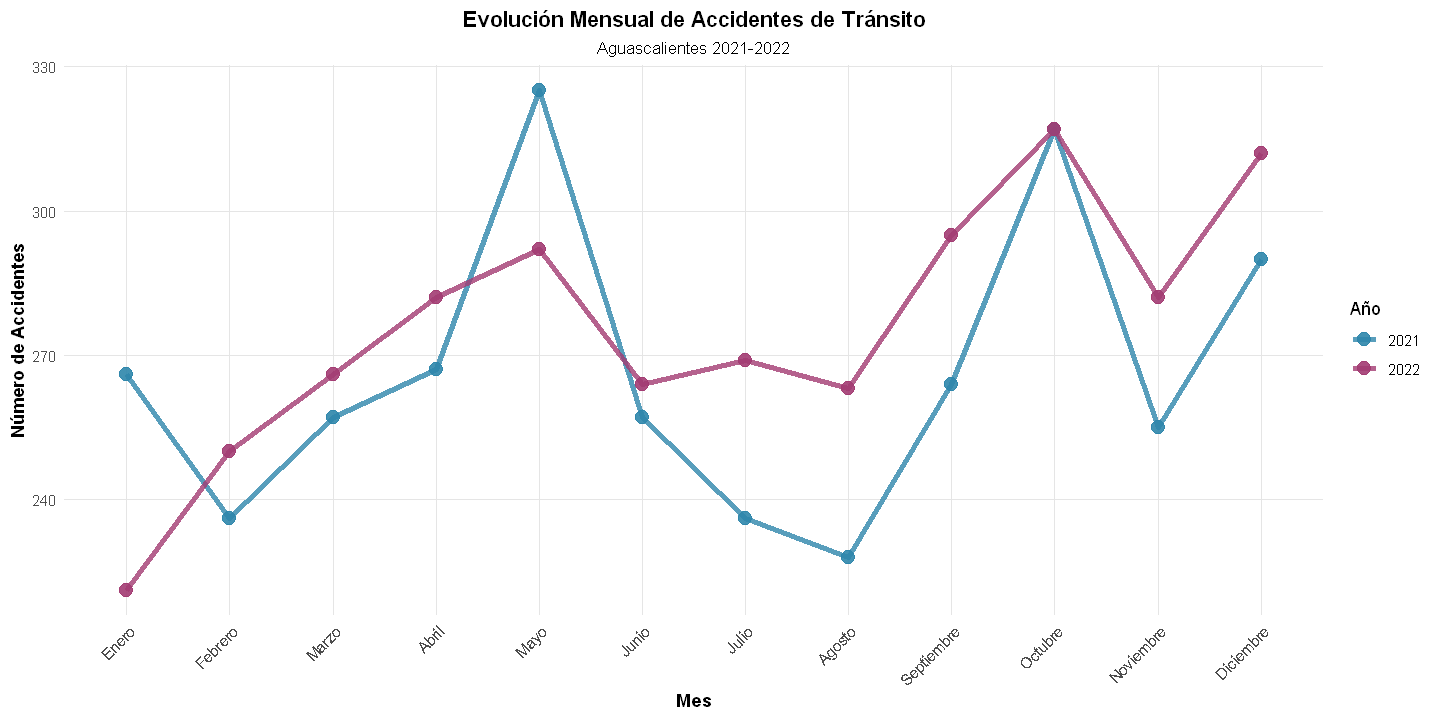

In [ ]:
# Preparar datos
accidentes_mes <- datos_completos %>%
  group_by(ANIO_FACTOR, mes_nombre) %>%
  summarise(cantidad = n(), .groups = "drop")

# Crear gráfico
options(repr.plot.width = 12, repr.plot.height = 6)

ggplot(accidentes_mes, aes(x = mes_nombre, y = cantidad,
                           color = ANIO_FACTOR, group = ANIO_FACTOR)) +
  geom_line(linewidth = 1.5, alpha = 0.8) +
  geom_point(linewidth = 3.5, alpha = 0.9) +
  scale_color_manual(values = c("2021" = "#2E86AB", "2022" = "#A23B72"),
                     name = "Año") +
  scale_y_continuous(labels = comma) +
  labs(title = "Evolución Mensual de Accidentes de Tránsito",
       subtitle = "Aguascalientes 2021-2022",
       x = "Mes",
       y = "Número de Accidentes") +
  theme_accidentes() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

**Interpretación:**

El análisis de la evolución mensual de accidentes en el estado de Aguascalientes durante 2021 y 2022 muestra un comportamiento relativamente estable con ciertos patrones estacionales. En términos generales, 2022 presenta un ligero incremento en el total anual de accidentes respecto a 2021 (aproximadamente 3.6% más).

En ambos años se observan picos importantes en los últimos meses, particularmente en octubre y diciembre, lo que sugiere una posible estacionalidad asociada al incremento de movilidad hacia el cierre del año. Además, mientras que 2021 presenta un pico marcado en mayo, 2022 muestra una tendencia más progresiva y sostenida de crecimiento a partir de marzo, especialmente en el segundo semestre.

**Hallazgos clave:**

- En 2022 hubo un aumento total de aproximadamente 115 accidentes respecto a 2021.
- Octubre es el mes con mayor número de accidentes en ambos años (317 casos), lo que indica un posible patrón recurrente.
- El segundo semestre de 2022 (julio–diciembre) muestra incrementos consistentes frente a 2021.
- Enero de 2022 registra una disminución notable respecto a enero de 2021.
- El último trimestre del año concentra algunos de los valores más altos en ambos periodos, lo que sugiere estacionalidad en los accidentes viales.

### Gráfico 2: Distribución por Día de la Semana

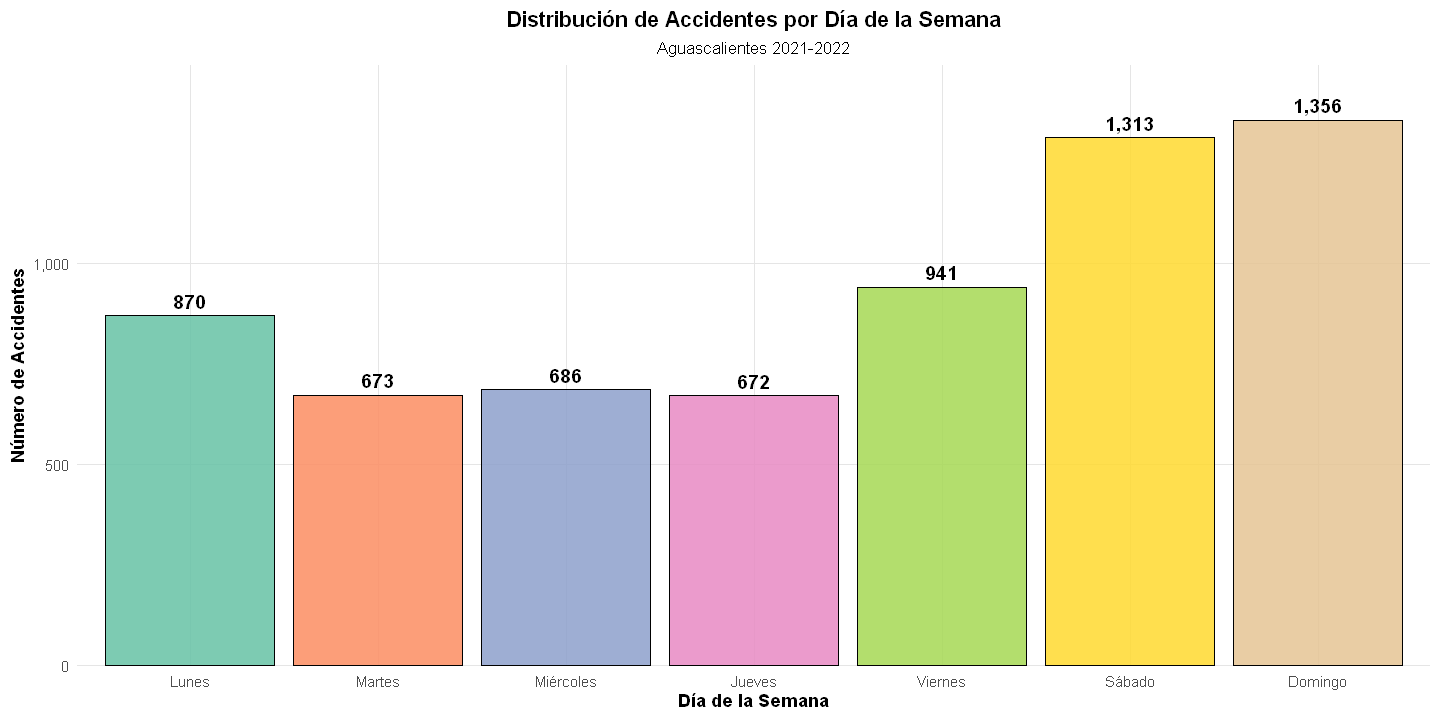

In [26]:
# Preparar datos
accidentes_dia <- datos_completos %>%
  filter(!is.na(dia_semana_nombre)) %>%
  group_by(dia_semana_nombre) %>%
  summarise(cantidad = n(), .groups = "drop")

# Crear gráfico
options(repr.plot.width = 12, repr.plot.height = 6)

ggplot(accidentes_dia,
       aes(x = dia_semana_nombre, y = cantidad, fill = dia_semana_nombre)) +
  geom_col(alpha = 0.85, color = "black", linewidth = 0.5) +
  geom_text(aes(label = comma(cantidad)),
            vjust = -0.5, fontface = "bold", size = 4) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.1))) +
  labs(title = "Distribución de Accidentes por Día de la Semana",
       subtitle = "Aguascalientes 2021-2022",
       x = "Día de la Semana",
       y = "Número de Accidentes") +
  theme_accidentes() +
  theme(legend.position = "none")

**Interpretación:**

La distribución de accidentes por día de la semana en el estado de Aguascalientes muestra una clara concentración hacia el fin de semana. Los días con mayor número de accidentes son sábado (1,313) y domingo (1,356), superando ampliamente a los días entre semana.

Durante los días laborales (lunes a viernes) se observa un comportamiento relativamente estable, con valores que oscilan entre 672 y 941 accidentes. Sin embargo, existe un incremento notable a partir del viernes, lo que sugiere un cambio en los patrones de movilidad y comportamiento vial conforme se acerca el fin de semana.

Esta distribución indica que los fines de semana representan los periodos de mayor riesgo en términos de frecuencia de accidentes.

**Hallazgos clave:**

- Domingo es el día con mayor número de accidentes (1,356), seguido de sábado (1,313).
- Los fines de semana concentran la mayor proporción de accidentes totales.
- Viernes presenta un incremento importante respecto a lunes–jueves, marcando el inicio de la tendencia ascendente.
- Martes y jueves son los días con menor número de accidentes.
- Existe un patrón claro de aumento progresivo hacia el fin de semana.

### Gráfico 3: Distribución Horaria de Accidentes

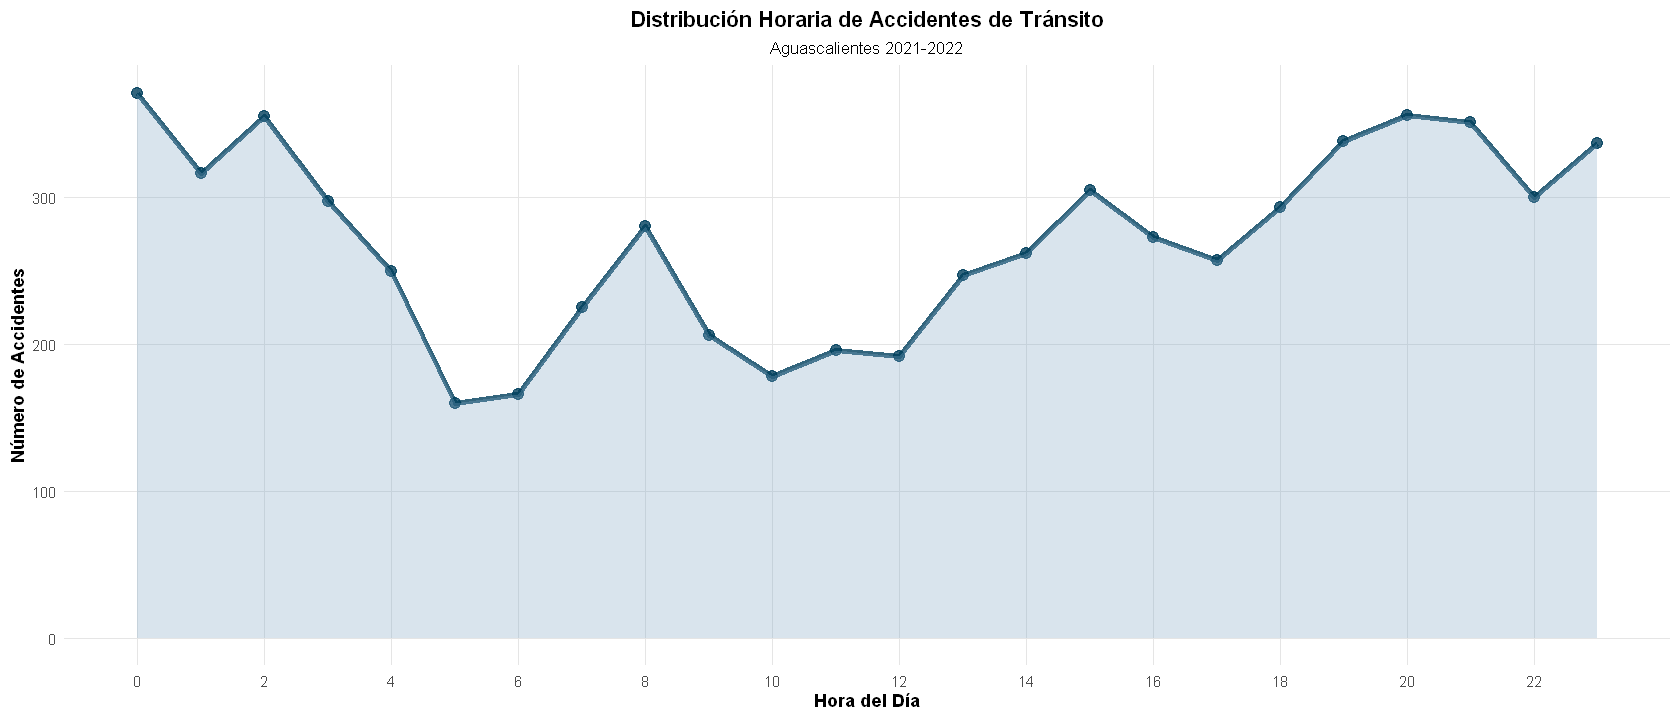

In [28]:
# Preparar datos
accidentes_hora <- datos_completos %>%
  filter(!is.na(HORA_LIMPIA)) %>%
  group_by(HORA_LIMPIA) %>%
  summarise(cantidad = n(), .groups = "drop")

# Crear gráfico
options(repr.plot.width = 14, repr.plot.height = 6)

ggplot(accidentes_hora, aes(x = HORA_LIMPIA, y = cantidad)) +
  geom_line(color = "#003f5c", size = 1.5, alpha = 0.8) +
  geom_point(color = "#003f5c", size = 3, alpha = 0.8) +
  geom_area(fill = "#7ea6c4", alpha = 0.3) +
  scale_x_continuous(breaks = seq(0, 23, 2)) +
  scale_y_continuous(labels = comma) +
  labs(title = "Distribución Horaria de Accidentes de Tránsito",
       subtitle = "Aguascalientes 2021-2022",
       x = "Hora del Día",
       y = "Número de Accidentes") +
  theme_accidentes()

**Interpretación:**

La distribución horaria de los accidentes en el estado de Aguascalientes muestra un patrón claramente diferenciado entre la madrugada, el día y la noche. Se observan niveles relativamente altos durante las primeras horas de la madrugada (00:00–02:00), una disminución marcada entre las 05:00 y 11:00 horas, y un incremento progresivo a partir de la tarde, con un segundo pico importante durante la noche.

El valor más bajo se registra a las 05:00 (160 accidentes), mientras que los valores más altos se concentran en la franja nocturna, especialmente a las 00:00 (371), 02:00 (355), 20:00 (356) y 21:00 (351). Esto sugiere que los periodos de mayor riesgo se ubican principalmente en horarios nocturnos y de transición entre tarde y noche.

En general, el comportamiento indica que los accidentes no se distribuyen de manera uniforme a lo largo del día, sino que presentan picos asociados a horarios de mayor actividad social y movilidad.

**Hallazgos clave:**

- La medianoche (00:00) es la hora con mayor número de accidentes (371).
- Existe un segundo bloque crítico entre las 19:00 y 23:00 horas, con valores superiores a 300 accidentes por hora.
- Las primeras horas de la mañana (05:00–06:00) presentan los niveles más bajos de accidentes.
- Se observa un aumento progresivo desde las 13:00 hasta las 16:00 horas.
- Los horarios nocturnos concentran la mayor frecuencia de accidentes, lo que sugiere mayor riesgo en ese periodo del día.

---
## Análisis de Severidad

Es crucial entender no solo cuántos accidentes ocurren, sino qué tan graves son sus consecuencias.

### Gráfico 4: Clasificación de Accidentes por Severidad

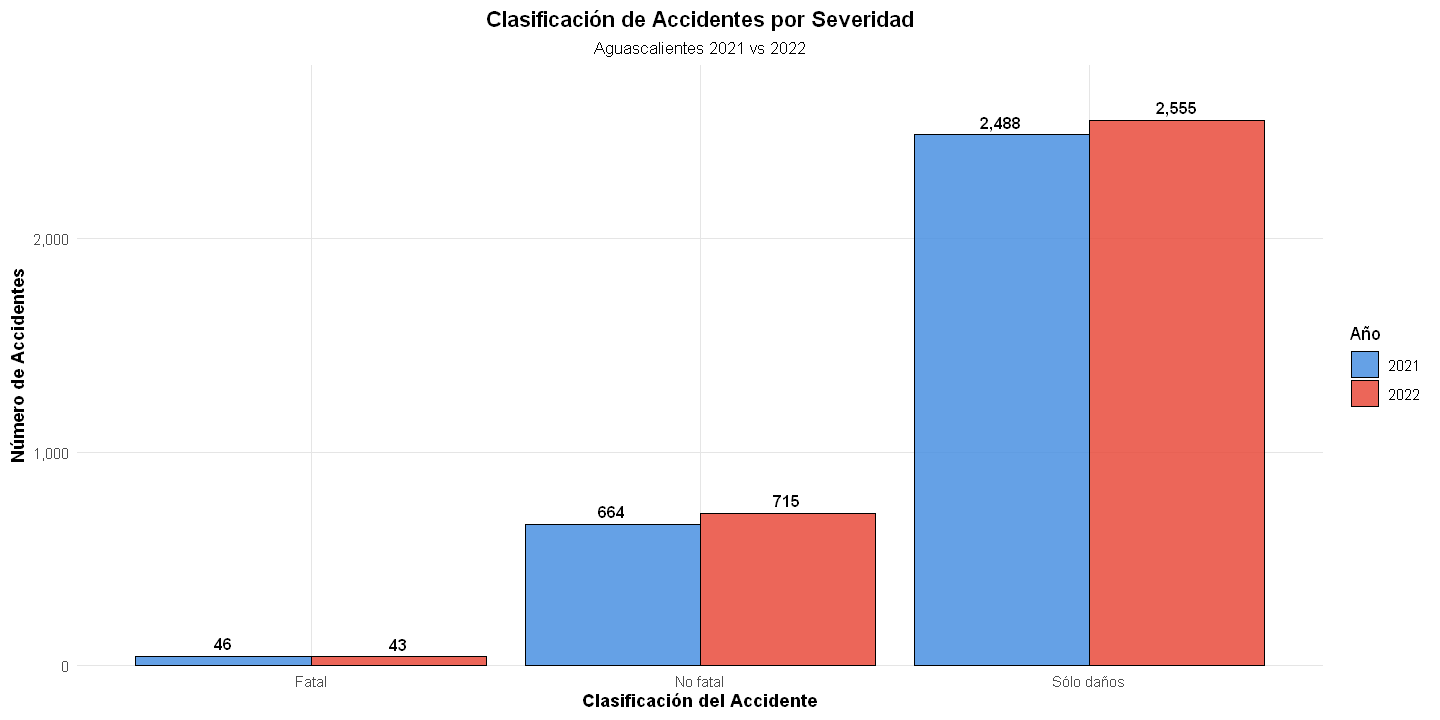

In [33]:
# Preparar datos
clasificacion <- datos_completos %>%
  filter(!is.na(clase_nombre)) %>%
  group_by(ANIO_FACTOR, clase_nombre) %>%
  summarise(cantidad = n(), .groups = "drop")

# Crear gráfico
options(repr.plot.width = 12, repr.plot.height = 6)

ggplot(clasificacion, aes(x = clase_nombre, y = cantidad, fill = ANIO_FACTOR)) +
  geom_col(position = "dodge", alpha = 0.85, color = "black", linewidth = 0.5) +
  geom_text(aes(label = comma(cantidad)),
            position = position_dodge(width = 0.9),
            vjust = -0.5, fontface = "bold", size = 3.5) +
  scale_fill_manual(values = c("2021" = "#4A90E2", "2022" = "#E94B3C"),
                    name = "Año") +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.1))) +
  labs(title = "Clasificación de Accidentes por Severidad",
       subtitle = "Aguascalientes 2021 vs 2022",
       x = "Clasificación del Accidente",
       y = "Número de Accidentes") +
  theme_accidentes()

**Interpretación:**

La clasificación de accidentes por severidad en el estado de Aguascalientes muestra que la gran mayoría de los eventos en ambos años corresponden a la categoría “Sólo daños”, seguida por los accidentes “No fatal”, mientras que los accidentes “Fatal” representan una proporción muy pequeña del total.

En 2021 se registraron 46 accidentes fatales, 664 no fatales y 2,488 de sólo daños. Para 2022, los accidentes fatales disminuyeron ligeramente a 43 casos, mientras que los no fatales aumentaron a 715 y los de sólo daños a 2,555. Esto indica que, aunque el total de accidentes aumentó en 2022, no hubo un incremento en la cantidad de accidentes fatales.

En términos proporcionales, los accidentes fatales representan cerca del 1–2% del total en ambos años, lo que sugiere que, si bien la frecuencia general de accidentes es considerable, la mayoría no implica pérdida de vidas.

**Hallazgos clave:**

- La categoría “Sólo daños” concentra la mayor proporción de accidentes en ambos años.
- En 2022 disminuyeron ligeramente los accidentes fatales (de 46 a 43).
- Los accidentes no fatales aumentaron en 2022 respecto a 2021.
- El incremento total de accidentes en 2022 se explica principalmente por el aumento en las categorías “No fatal” y “Sólo daños”.
- Los accidentes fatales representan una proporción reducida del total en ambos periodos.

### Gráfico 5: Total de Víctimas

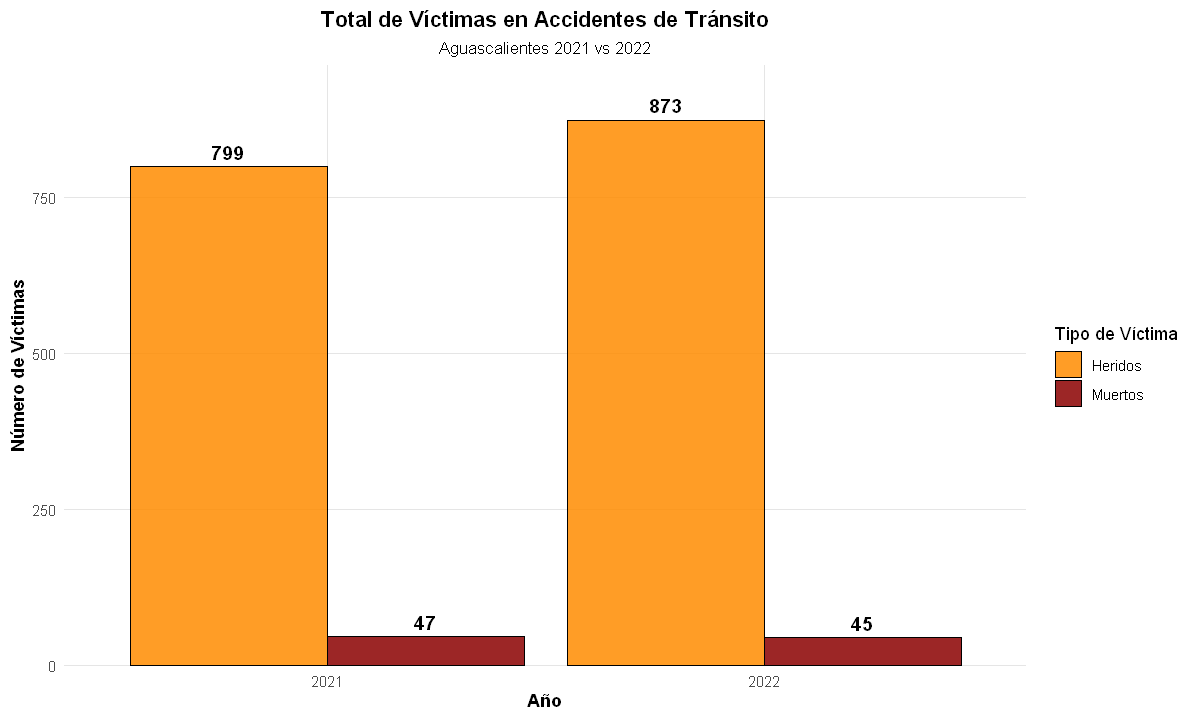

In [35]:
# Preparar datos
victimas <- datos_completos %>%
  group_by(ANIO_FACTOR) %>%
  summarise(
    Muertos = sum(TOTMUERTOS, na.rm = TRUE),
    Heridos = sum(TOTHERIDOS, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  pivot_longer(cols = c(Muertos, Heridos),
               names_to = "tipo",
               values_to = "cantidad")

# Crear gráfico
options(repr.plot.width = 10, repr.plot.height = 6)

ggplot(victimas, aes(x = ANIO_FACTOR, y = cantidad, fill = tipo)) +
  geom_col(position = "dodge", alpha = 0.85, color = "black", linewidth = 0.5) +
  geom_text(aes(label = comma(cantidad)),
            position = position_dodge(width = 0.9),
            vjust = -0.5, fontface = "bold", size = 4) +
  scale_fill_manual(values = c("Muertos" = "#8B0000", "Heridos" = "#FF8C00"),
                    name = "Tipo de Víctima") +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.1))) +
  labs(title = "Total de Víctimas en Accidentes de Tránsito",
       subtitle = "Aguascalientes 2021 vs 2022",
       x = "Año",
       y = "Número de Víctimas") +
  theme_accidentes()

**Interpretación:**

El total de víctimas en accidentes de tránsito en el estado de Aguascalientes muestra un comportamiento mixto entre 2021 y 2022. Mientras que el número de personas fallecidas disminuyó ligeramente (de 47 a 45), la cantidad de personas heridas aumentó de manera más considerable (de 799 a 873).

Este comportamiento indica que, aunque la letalidad de los accidentes no se incrementó, sí hubo un aumento en la cantidad de personas lesionadas. Esto puede estar relacionado con el incremento general en el número de accidentes observado en 2022.

En términos generales, las personas heridas representan la gran mayoría de las víctimas en ambos años, lo que confirma que la principal consecuencia de los accidentes de tránsito es la generación de lesiones más que fallecimientos.

**Hallazgos clave:**

- Las muertes disminuyeron ligeramente en 2022 (de 47 a 45).
- Las personas heridas aumentaron en 2022 (de 799 a 873).
- La mayor parte de las víctimas corresponde a personas lesionadas.
- El incremento en víctimas totales en 2022 se debe principalmente al aumento de heridos.
- No se observa un incremento en la mortalidad a pesar del aumento general de accidentes.

### Gráfico 6: Severidad por Tipo de Accidente

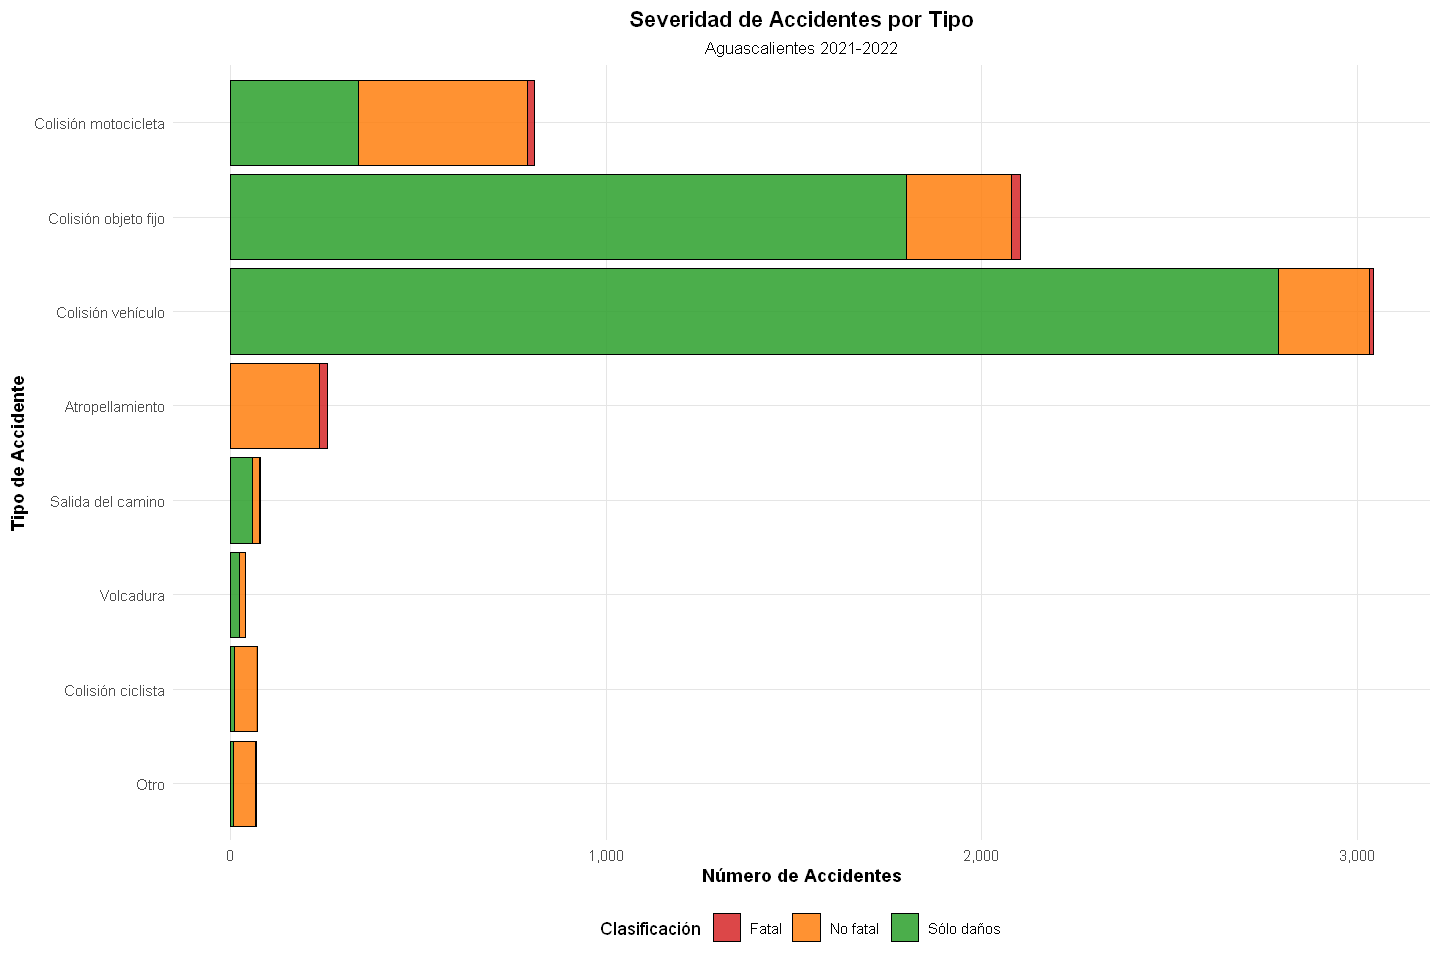

In [37]:
# Preparar datos - Top 8 tipos
top_tipos <- datos_completos %>%
  filter(!is.na(tipo_accidente_nombre)) %>%
  count(tipo_accidente_nombre, sort = TRUE) %>%
  head(8) %>%
  pull(tipo_accidente_nombre)

severidad_tipo <- datos_completos %>%
  filter(tipo_accidente_nombre %in% top_tipos,
         !is.na(clase_nombre)) %>%
  group_by(tipo_accidente_nombre, clase_nombre) %>%
  summarise(cantidad = n(), .groups = "drop")

# Crear gráfico
options(repr.plot.width = 12, repr.plot.height = 8)

ggplot(
       severidad_tipo,
       aes(x = cantidad, y = fct_reorder(tipo_accidente_nombre, cantidad),
           fill = clase_nombre)) +
  geom_col(alpha = 0.85, color = "black", linewidth = 0.3) +
  scale_fill_manual(values = c("Fatal" = "#d62728",
                               "No fatal" = "#ff7f0e",
                               "Sólo daños" = "#2ca02c"),
                    name = "Clasificación") +
  scale_x_continuous(labels = comma) +
  labs(title = "Severidad de Accidentes por Tipo",
       subtitle = "Aguascalientes 2021-2022",
       x = "Número de Accidentes",
       y = "Tipo de Accidente") +
  theme_accidentes() +
  theme(legend.position = "bottom")

**Interpretación:**

El análisis de la severidad de accidentes por tipo en el estado de Aguascalientes muestra que las colisiones entre vehículos concentran la mayor cantidad total de accidentes, principalmente en la categoría “Sólo daños”. Sin embargo, cuando se analiza la severidad en términos de fatalidades, destacan otros tipos de accidentes como el atropellamiento, la colisión con objeto fijo y la colisión con motocicleta.

La “Colisión vehículo” registra el mayor volumen total (especialmente en “Sólo daños” con 2,789 casos), lo que indica que es el tipo de accidente más frecuente. No obstante, los atropellamientos presentan una proporción considerable de casos fatales (22), lo que evidencia una mayor vulnerabilidad de los peatones. Asimismo, las colisiones con objeto fijo (25 fatales) y las colisiones con motocicleta (18 fatales) también representan focos importantes de riesgo en términos de gravedad.

En contraste, tipos como volcadura, salida del camino y colisión ciclista presentan menores volúmenes totales, aunque algunos mantienen presencia en la categoría fatal, lo que sugiere que, aunque menos frecuentes, pueden implicar alto riesgo.

**Hallazgos clave:**

- La “Colisión vehículo” es el tipo de accidente más frecuente, principalmente en la categoría “Sólo daños”.
- La “Colisión objeto fijo” es el tipo con mayor número de casos fatales (25).
- El “Atropellamiento” presenta una alta cantidad de accidentes fatales (22), reflejando la vulnerabilidad del peatón.
- La “Colisión motocicleta” concentra una cantidad importante de casos no fatales (449) y también presenta 18 fatales.
- Aunque menos frecuentes, eventos como volcadura y salida del camino también registran casos fatales, lo que indica que no deben subestimarse en términos de riesgo.
- La mayoría de los accidentes, independientemente del tipo, se concentran en la categoría “Sólo daños”.

---
## Análisis de Causas y Factores

Identificar las causas de los accidentes es fundamental para diseñar estrategias de prevención efectivas.

### Gráfico 7: Principales Causas de Accidentes

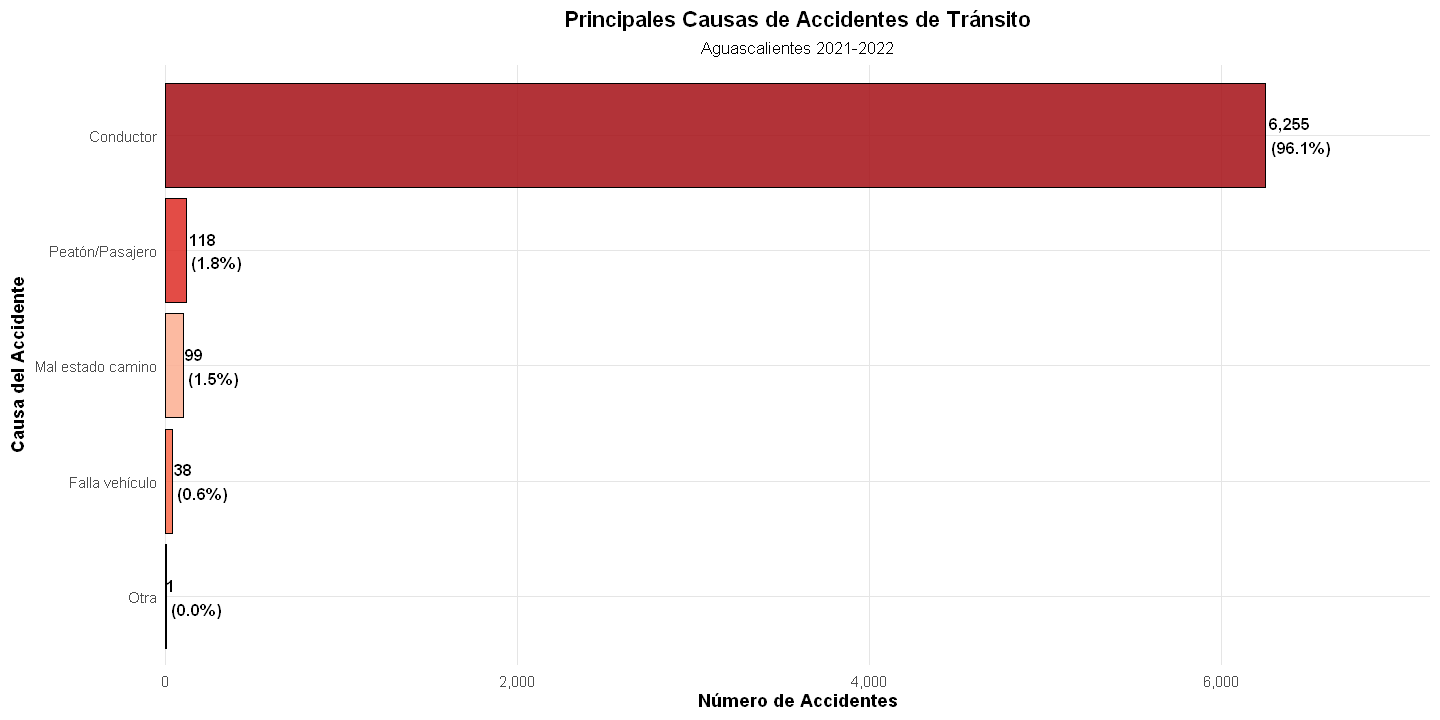

In [41]:
# Preparar datos
causas <- datos_completos %>%
  filter(!is.na(causa_nombre)) %>%
  count(causa_nombre, sort = TRUE) %>%
  mutate(porcentaje = n / sum(n) * 100)

# Crear gráfico
options(repr.plot.width = 12, repr.plot.height = 6)

ggplot(causas,
       aes(x = n, y = fct_reorder(causa_nombre, n), fill = causa_nombre)) +
  geom_col(alpha = 0.85, color = "black", linewidth = 0.5) +
  geom_text(aes(label = sprintf("%s\n(%.1f%%)", comma(n), porcentaje)),
            hjust = -0.1, fontface = "bold", size = 3.5) +
  scale_fill_brewer(palette = "Reds", direction = -1) +
  scale_x_continuous(labels = comma, expand = expansion(mult = c(0, 0.15))) +
  labs(title = "Principales Causas de Accidentes de Tránsito",
       subtitle = "Aguascalientes 2021-2022",
       x = "Número de Accidentes",
       y = "Causa del Accidente") +
  theme_accidentes() +
  theme(legend.position = "none")

**Interpretación:**

La distribución de las principales causas de accidentes de tránsito en el estado de Aguascalientes muestra una concentración abrumadora en factores atribuibles al conductor. Con 6,255 casos (96.07%), la conducta o error humano del conductor representa prácticamente la totalidad de los accidentes registrados.

En contraste, las demás causas tienen una participación mínima: peatón/pasajero (1.81%), mal estado del camino (1.52%), fallas del vehículo (0.58%) y otras causas (0.02%). Esto indica que los factores humanos superan ampliamente a los factores mecánicos o de infraestructura como origen de los accidentes.

El patrón observado sugiere que las estrategias de prevención deberían enfocarse prioritariamente en educación vial, control de conductas de riesgo y cumplimiento normativo.

**Hallazgos clave:**

- El 96.07% de los accidentes son atribuibles al conductor.
- Las causas relacionadas con infraestructura (mal estado del camino) representan apenas 1.52%.
- Las fallas mecánicas del vehículo constituyen menos del 1% del total.
- La participación de peatón/pasajero como causa directa es reducida (1.81%).
- El factor humano es el principal determinante en la ocurrencia de accidentes.

### Gráfico 8: Tipos de Accidente más Frecuentes

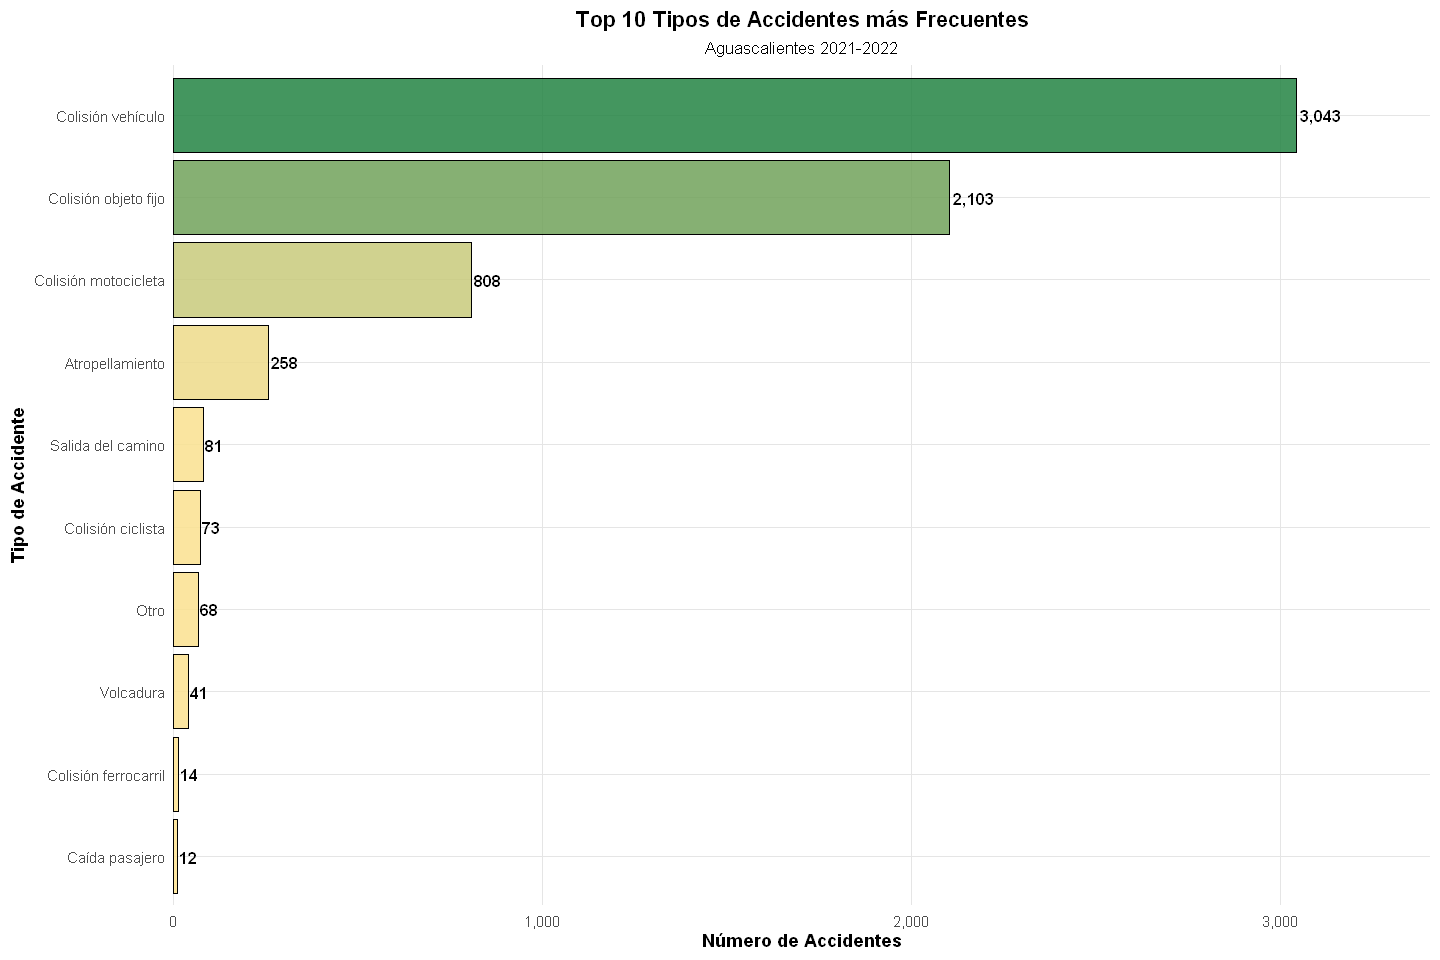

In [43]:
# Preparar datos
tipos <- datos_completos %>%
  filter(!is.na(tipo_accidente_nombre)) %>%
  count(tipo_accidente_nombre, sort = TRUE) %>%
  head(10)

# Crear gráfico
options(repr.plot.width = 12, repr.plot.height = 8)

ggplot(tipos, aes(x = n, y = fct_reorder(tipo_accidente_nombre, n))) +
  geom_col(aes(fill = n), alpha = 0.85, color = "black", linewidth = 0.5) +
  geom_text(aes(label = comma(n)),
            hjust = -0.1,
            fontface = "bold",
            size = 3.5) +
  scale_fill_gradient(low = "#FEE391", high = "#238443") +
  scale_x_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  labs(title = "Top 10 Tipos de Accidentes más Frecuentes",
       subtitle = "Aguascalientes 2021-2022",
       x = "Número de Accidentes",
       y = "Tipo de Accidente") +
  theme_accidentes() +
  theme(legend.position = "none")

**Interpretación:**

El análisis del Top 10 de tipos de accidentes más frecuentes en el estado de Aguascalientes muestra una alta concentración en las colisiones entre vehículos, las cuales representan el tipo más común con 3,043 casos. Le siguen las colisiones contra objeto fijo (2,103) y las colisiones con motocicleta (808), lo que indica que la mayoría de los incidentes están relacionados con impactos directos entre vehículos o contra infraestructura.

A partir del cuarto lugar, la frecuencia disminuye considerablemente. El atropellamiento (258) mantiene relevancia por su impacto en la vulnerabilidad de peatones, mientras que eventos como salida del camino, colisión ciclista, volcadura y colisión con ferrocarril presentan volúmenes mucho menores.

La distribución evidencia que los accidentes más frecuentes están vinculados principalmente a dinámicas de circulación vehicular y posibles errores de conducción.

**Hallazgos clave:**

- La “Colisión vehículo” es el tipo de accidente más frecuente (3,043 casos).
- La “Colisión objeto fijo” ocupa el segundo lugar con 2,103 casos.
- La “Colisión motocicleta” es el tercer tipo más común (808 casos).
- A partir del cuarto lugar, la frecuencia disminuye de manera significativa.
- Los accidentes relacionados con trenes y caídas de pasajeros son poco frecuentes.
- La mayoría de los accidentes frecuentes están asociados a colisiones vehiculares.

### Gráfico 9: Relación entre Alcohol y Severidad

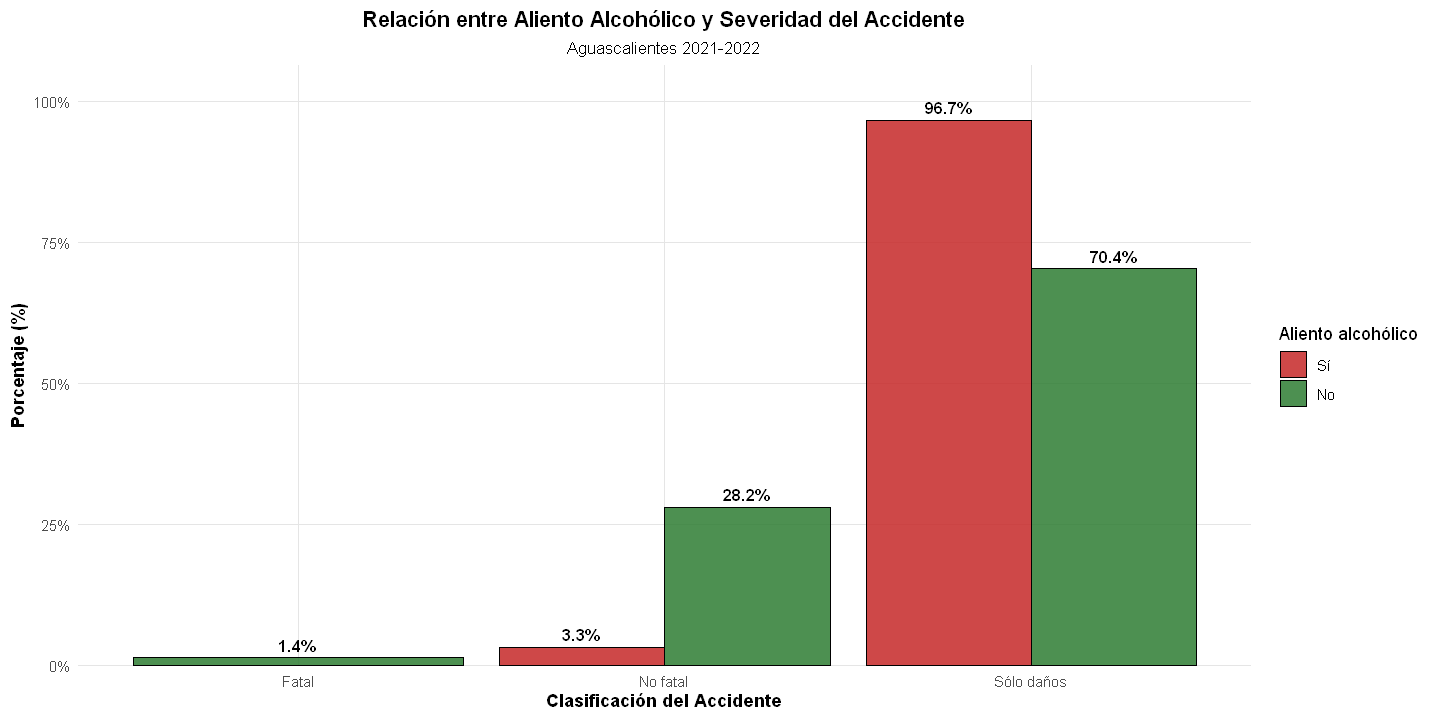

In [46]:
# Preparar datos
alcohol_severidad <- datos_completos %>%
  filter(aliento_alcoholico %in% c("Sí", "No"),
         !is.na(clase_nombre)) %>%
  group_by(aliento_alcoholico, clase_nombre) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(aliento_alcoholico) %>%
  mutate(porcentaje = n / sum(n) * 100)

# Crear gráfico
options(repr.plot.width = 12, repr.plot.height = 6)

ggplot(alcohol_severidad, aes(x = clase_nombre, y = porcentaje,
                              fill = aliento_alcoholico)) +
  geom_col(position = "dodge", alpha = 0.85, color = "black", linewidth = 0.5) +
  geom_text(aes(label = sprintf("%.1f%%", porcentaje)),
            position = position_dodge(width = 0.9),
            vjust = -0.5, fontface = "bold", size = 3.5) +
  scale_fill_manual(values = c("No" = "#2E7D32", "Sí" = "#C62828"),
                    name = "Aliento alcohólico") +
  scale_y_continuous(labels = function(x) paste0(x, "%"),
                     expand = expansion(mult = c(0, 0.1))) +
  labs(title = "Relación entre Aliento Alcohólico y Severidad del Accidente",
       subtitle = "Aguascalientes 2021-2022",
       x = "Clasificación del Accidente",
       y = "Porcentaje (%)") +
  theme_accidentes()

**Interpretación:**

El análisis de la relación entre presencia de aliento alcohólico y severidad del accidente en el estado de Aguascalientes muestra diferencias importantes en la distribución de la gravedad.

En los casos donde se reportó aliento alcohólico (“Sí”), la gran mayoría de los accidentes fueron clasificados como “Sólo daños” (96.67%), mientras que una pequeña proporción correspondió a accidentes “No fatal” (3.33%). No se registran casos fatales en esta categoría dentro de los datos presentados.

En contraste, cuando no se detectó aliento alcohólico (“No”), se observa presencia en las tres categorías de severidad, incluyendo accidentes fatales (1.44%), además de una proporción considerable de accidentes no fatales (28.16%) y sólo daños (70.40%).

En términos generales, aunque el alcohol está presente en ciertos eventos, la mayor cantidad absoluta de accidentes —incluidos los fatales— ocurre en casos donde no se reportó aliento alcohólico, lo que puede estar relacionado con una mayor frecuencia total de accidentes sin consumo detectado.

**Hallazgos clave:**

- En casos con aliento alcohólico, el 96.67% corresponde a accidentes con “Sólo daños”.
- No se registran accidentes fatales en la categoría con aliento alcohólico dentro de los datos proporcionados.
- En ausencia de aliento alcohólico, sí se presentan accidentes fatales (1.44%).
- Los accidentes no fatales son considerablemente más frecuentes cuando no hay presencia de alcohol detectada.
- La mayor parte de los accidentes totales ocurre en casos sin registro de aliento alcohólico.

### Gráfico 10: Impacto del Uso de Cinturón de Seguridad

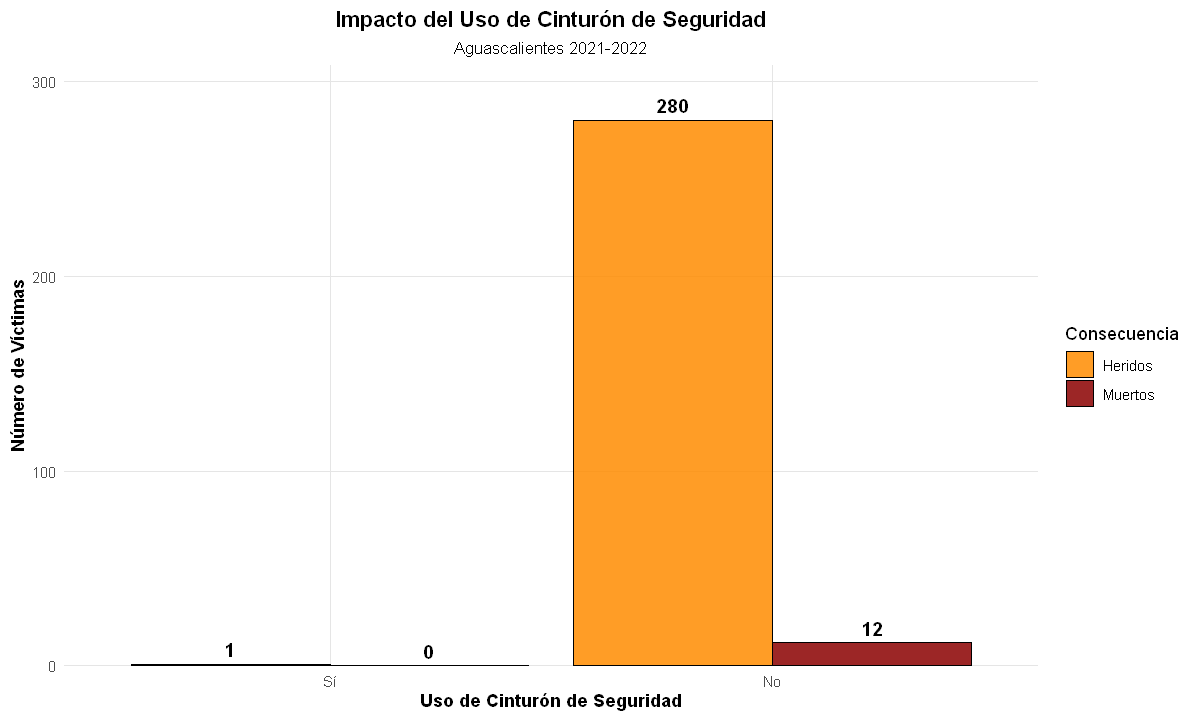

In [49]:
# Preparar datos
cinturon_consecuencias <- datos_completos %>%
  filter(uso_cinturon %in% c("Sí", "No")) %>%
  group_by(uso_cinturon) %>%
  summarise(
    Muertos = sum(CONDMUERTO, na.rm = TRUE),
    Heridos = sum(CONDHERIDO, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  pivot_longer(cols = c(Muertos, Heridos),
               names_to = "consecuencia",
               values_to = "cantidad")

# Crear gráfico
options(repr.plot.width = 10, repr.plot.height = 6)

ggplot(cinturon_consecuencias, aes(x = uso_cinturon, y = cantidad,
                                   fill = consecuencia)) +
  geom_col(position = "dodge", alpha = 0.85, color = "black", linewidth = 0.5) +
  geom_text(aes(label = comma(cantidad)),
            position = position_dodge(width = 0.9),
            vjust = -0.5, fontface = "bold", size = 4) +
  scale_fill_manual(values = c("Muertos" = "#8B0000", "Heridos" = "#FF8C00"),
                    name = "Consecuencia") +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.1))) +
  labs(title = "Impacto del Uso de Cinturón de Seguridad",
       subtitle = "Aguascalientes 2021-2022",
       x = "Uso de Cinturón de Seguridad",
       y = "Número de Víctimas") +
  theme_accidentes()

**Interpretación:**

El análisis del impacto del uso del cinturón de seguridad en el estado de Aguascalientes muestra una diferencia marcada en las consecuencias de los accidentes según su utilización.

En los casos donde se reportó uso de cinturón (“Sí”), no se registraron personas fallecidas y únicamente se presentó 1 persona herida. En contraste, cuando no se utilizó cinturón (“No”), se registraron 12 personas fallecidas y 280 personas heridas.

Estos datos evidencian una asociación clara entre la falta de uso del cinturón de seguridad y una mayor gravedad en las consecuencias del accidente. Aunque el volumen de casos con uso registrado es bajo en los datos proporcionados, el patrón sugiere que el cinturón cumple una función protectora significativa al reducir el riesgo de lesiones graves y muertes.

**Hallazgos clave:**

- No se registraron muertes en casos donde se utilizó cinturón de seguridad.
- Solo se presentó 1 persona herida con uso de cinturón.
- En ausencia de cinturón se registraron 12 muertes.
- La gran mayoría de las lesiones (280) ocurrió cuando no se utilizó cinturón.
- Los datos respaldan la importancia del uso del cinturón como medida de protección vial.

---
## Análisis de Vehículos

El tipo de vehículo involucrado puede influir significativamente en el riesgo y severidad de los accidentes.

### Gráfico 11: Vehículos Involucrados en Accidentes

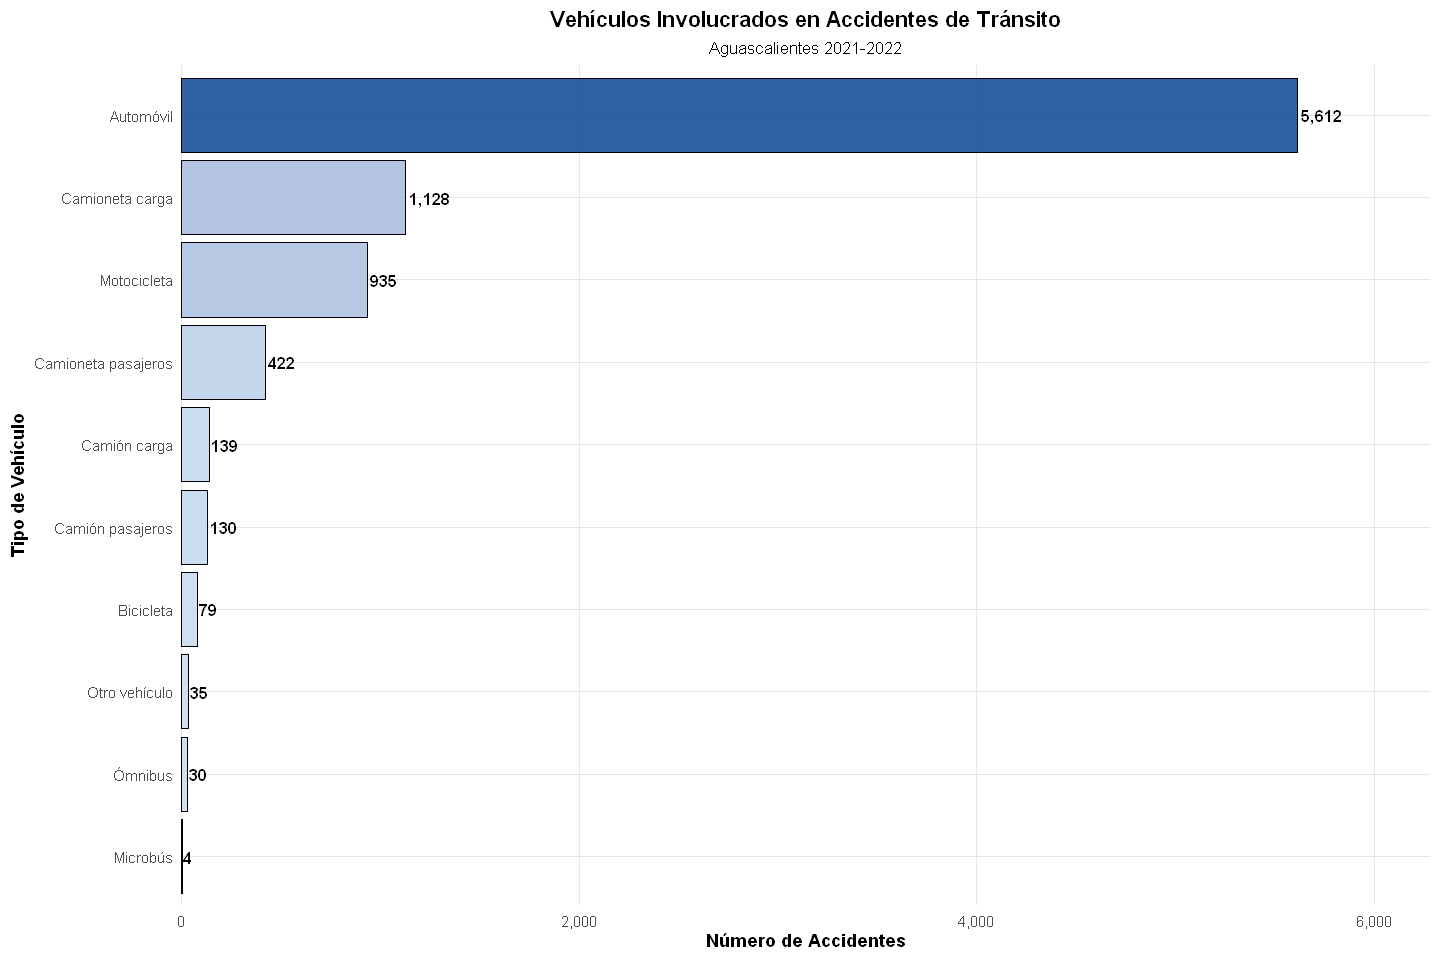

In [51]:
# Preparar datos
vehiculos <- data.frame(
  tipo = c("Automóvil", "Camioneta pasajeros", "Microbús", "Camión pasajeros",
           "Ómnibus", "Camioneta carga", "Camión carga", "Motocicleta",
           "Bicicleta", "Otro vehículo"),
  cantidad = c(
    sum(datos_completos$AUTOMOVIL > 0, na.rm = TRUE),
    sum(datos_completos$CAMPASAJ > 0, na.rm = TRUE),
    sum(datos_completos$MICROBUS > 0, na.rm = TRUE),
    sum(datos_completos$PASCAMION > 0, na.rm = TRUE),
    sum(datos_completos$OMNIBUS > 0, na.rm = TRUE),
    sum(datos_completos$CAMIONETA > 0, na.rm = TRUE),
    sum(datos_completos$CAMION > 0, na.rm = TRUE),
    sum(datos_completos$MOTOCICLET > 0, na.rm = TRUE),
    sum(datos_completos$BICICLETA > 0, na.rm = TRUE),
    sum(datos_completos$OTROVEHIC > 0, na.rm = TRUE)
  )
) %>%
  arrange(cantidad)

# Crear gráfico
options(repr.plot.width = 12, repr.plot.height = 8)

ggplot(vehiculos, aes(x = cantidad, y = fct_reorder(tipo, cantidad))) +
  geom_col(aes(fill = cantidad),
           alpha = 0.85,
           color = "black",
           linewidth = 0.5) +
  geom_text(aes(label = comma(cantidad)), hjust = -0.1,
            fontface = "bold", size = 3.5) +
  scale_fill_gradient(low = "#C6DBEF", high = "#084594") +
  scale_x_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  labs(title = "Vehículos Involucrados en Accidentes de Tránsito",
       subtitle = "Aguascalientes 2021-2022",
       x = "Número de Accidentes",
       y = "Tipo de Vehículo") +
  theme_accidentes() +
  theme(legend.position = "none")

**Interpretación:**

La distribución de vehículos involucrados en accidentes de tránsito en el estado de Aguascalientes muestra una clara concentración en vehículos particulares. El automóvil es, con amplia diferencia, el tipo de vehículo más involucrado (5,612 casos), seguido por camioneta de carga (1,128) y motocicleta (935).

Los vehículos de transporte público como ómnibus (30), microbús (4) y camión de pasajeros (130) presentan una participación mucho menor en comparación con los vehículos privados. Asimismo, la bicicleta (79) aparece con una frecuencia relativamente baja, aunque su presencia es relevante en términos de vulnerabilidad vial.

En general, los datos reflejan que la mayor parte de los accidentes está asociada a vehículos de uso particular, lo que puede estar relacionado con su mayor presencia en el parque vehicular y en la movilidad diaria.

**Hallazgos clave:**

- El automóvil es el vehículo más involucrado en accidentes (5,612 casos).
- Las camionetas de carga (1,128) y motocicletas (935) ocupan el segundo y tercer lugar respectivamente.
- Los vehículos de transporte público presentan una participación considerablemente menor.
- Las motocicletas representan un grupo relevante dentro de los vehículos con alta frecuencia de accidentes.
- La mayoría de los accidentes involucra vehículos particulares.

### Gráfico 12: Análisis Comparativo de Accidentes con Motocicletas

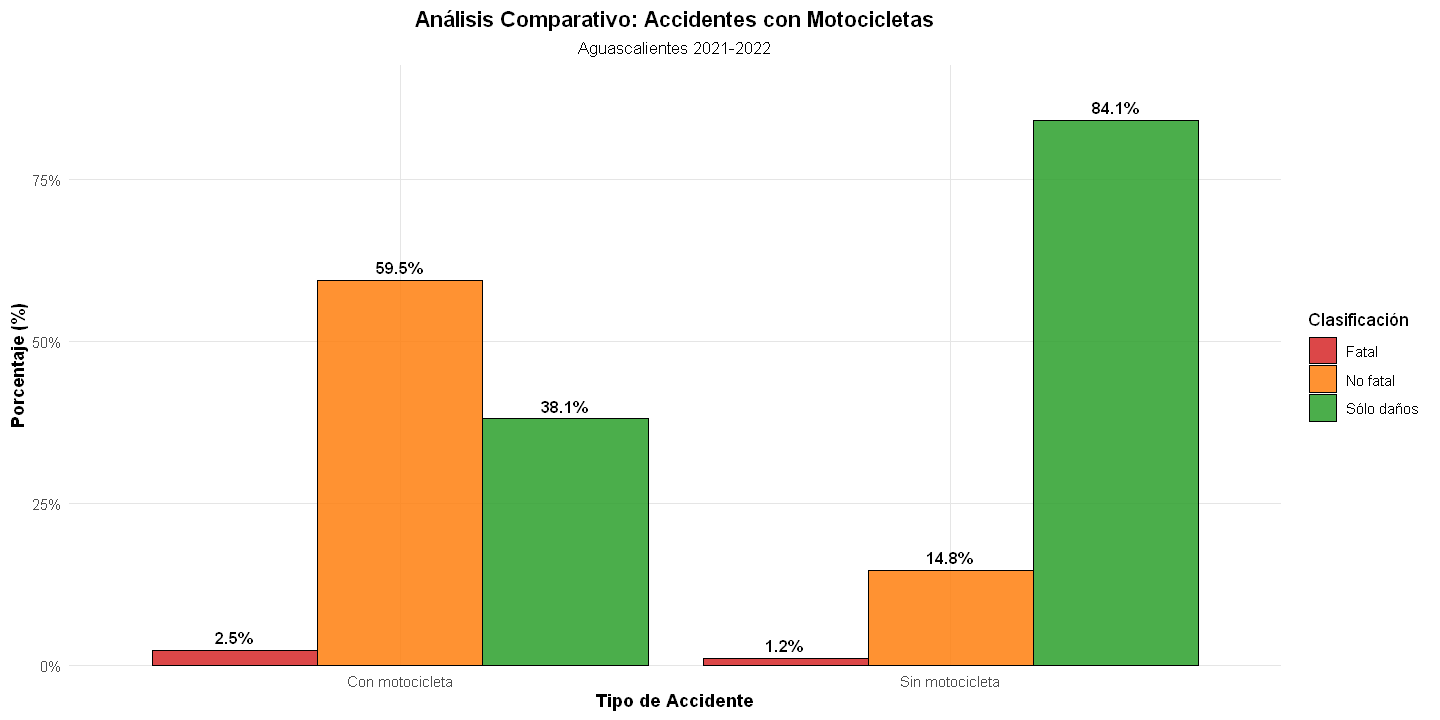

In [53]:
# Preparar datos
moto_analisis <- datos_completos %>%
  mutate(con_moto = ifelse(MOTOCICLET > 0,
                           "Con motocicleta",
                           "Sin motocicleta")) %>%
  filter(!is.na(clase_nombre)) %>%
  group_by(con_moto, clase_nombre) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(con_moto) %>%
  mutate(porcentaje = n / sum(n) * 100)

# Crear gráfico
options(repr.plot.width = 12, repr.plot.height = 6)

ggplot(moto_analisis, aes(x = con_moto, y = porcentaje, fill = clase_nombre)) +
  geom_col(position = "dodge", alpha = 0.85, color = "black", linewidth = 0.5) +
  geom_text(aes(label = sprintf("%.1f%%", porcentaje)),
            position = position_dodge(width = 0.9),
            vjust = -0.5, fontface = "bold", size = 3.5) +
  scale_fill_manual(values = c("Fatal" = "#d62728",
                               "No fatal" = "#ff7f0e",
                               "Sólo daños" = "#2ca02c"),
                    name = "Clasificación") +
  scale_y_continuous(labels = function(x) paste0(x, "%"),
                     expand = expansion(mult = c(0, 0.1))) +
  labs(title = "Análisis Comparativo: Accidentes con Motocicletas",
       subtitle = "Aguascalientes 2021-2022",
       x = "Tipo de Accidente",
       y = "Porcentaje (%)") +
  theme_accidentes()

**Interpretación:**

El análisis comparativo entre accidentes con y sin motocicleta en el estado de Aguascalientes muestra diferencias claras en la severidad de los eventos.

En los accidentes **con motocicleta**, la proporción de casos “No fatal” es la más alta (59.47%), seguida por “Sólo daños” (38.07%) y una proporción de accidentes “Fatal” de 2.46%. En contraste, en los accidentes **sin motocicleta**, la mayoría corresponde a “Sólo daños” (84.06%), mientras que los “No fatal” representan 14.76% y los “Fatal” 1.18%.

Esto indica que los accidentes que involucran motocicletas tienden a presentar una mayor proporción de lesiones y una tasa de fatalidad relativamente más alta en comparación con aquellos donde no participan motocicletas. Por el contrario, los accidentes sin motocicleta se concentran predominantemente en daños materiales.

En términos generales, los datos sugieren que la motocicleta es un factor asociado a mayor gravedad en los accidentes de tránsito.

**Hallazgos clave:**

- Los accidentes con motocicleta presentan una mayor proporción de casos no fatales (59.47%) en comparación con los accidentes sin motocicleta.
- La tasa de accidentes fatales es mayor cuando hay motocicleta involucrada (2.46% vs 1.18%).
- Los accidentes sin motocicleta se concentran principalmente en la categoría “Sólo daños” (84.06%).
- La participación de motocicletas se asocia con mayor probabilidad de lesiones.
- Los accidentes con motocicleta tienden a ser más graves en comparación con aquellos sin motocicleta.

---
## Análisis Geoespacial

La ubicación de los accidentes (urbana vs suburbana) puede revelar diferencias importantes en los patrones de riesgo.

### Gráfico 13: Accidentes en Zonas Urbanas vs Suburbanas

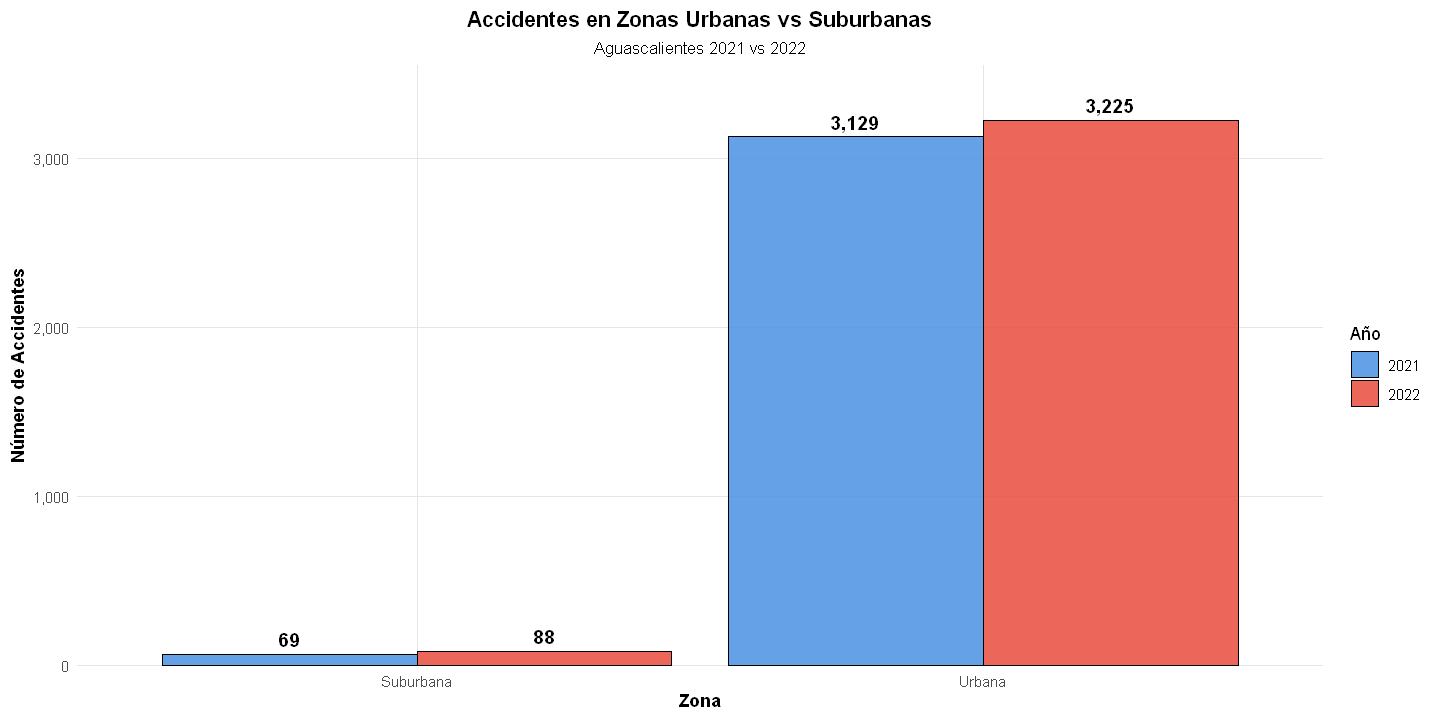

In [55]:
# Preparar datos
zonas <- datos_completos %>%
  group_by(ANIO_FACTOR, zona) %>%
  summarise(cantidad = n(), .groups = "drop")

# Crear gráfico
options(repr.plot.width = 12, repr.plot.height = 6)

ggplot(zonas, aes(x = zona, y = cantidad, fill = ANIO_FACTOR)) +
  geom_col(position = "dodge", alpha = 0.85, color = "black", linewidth = 0.5) +
  geom_text(aes(label = comma(cantidad)),
            position = position_dodge(width = 0.9),
            vjust = -0.5, fontface = "bold", size = 4) +
  scale_fill_manual(values = c("2021" = "#4A90E2", "2022" = "#E94B3C"),
                    name = "Año") +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.1))) +
  labs(title = "Accidentes en Zonas Urbanas vs Suburbanas",
       subtitle = "Aguascalientes 2021 vs 2022",
       x = "Zona",
       y = "Número de Accidentes") +
  theme_accidentes()

**Interpretación:**

El análisis de los accidentes en zonas urbanas y suburbanas en el estado de Aguascalientes muestra una concentración abrumadora en zonas urbanas durante ambos años.

En 2021 se registraron 3,129 accidentes en zona urbana frente a 69 en zona suburbana. Para 2022, los accidentes urbanos aumentaron a 3,225, mientras que en zona suburbana se registraron 88 casos. Esto indica que más del 95% de los accidentes ocurren en áreas urbanas.

El incremento observado en 2022 se presenta tanto en zonas urbanas como suburbanas; sin embargo, el aumento absoluto es mucho más significativo en las zonas urbanas debido a su mayor volumen.

En términos generales, la alta concentración en zonas urbanas puede estar relacionada con mayor densidad vehicular, tráfico constante e interacciones más frecuentes entre vehículos y peatones.

**Hallazgos clave:**

- La gran mayoría de los accidentes ocurre en zonas urbanas en ambos años.
- En 2022 se observa un incremento tanto en zona urbana como suburbana.
- Las zonas suburbanas representan una proporción muy pequeña del total de accidentes.
- El aumento total de accidentes en 2022 se explica principalmente por el crecimiento en zonas urbanas.
- La concentración urbana sugiere mayor exposición al riesgo debido a densidad y movilidad.

---
## Análisis del Perfil del Conductor

Las características del conductor (edad y género) pueden ayudar a identificar grupos de mayor riesgo.

### Gráfico 14: Distribución por Edad del Conductor

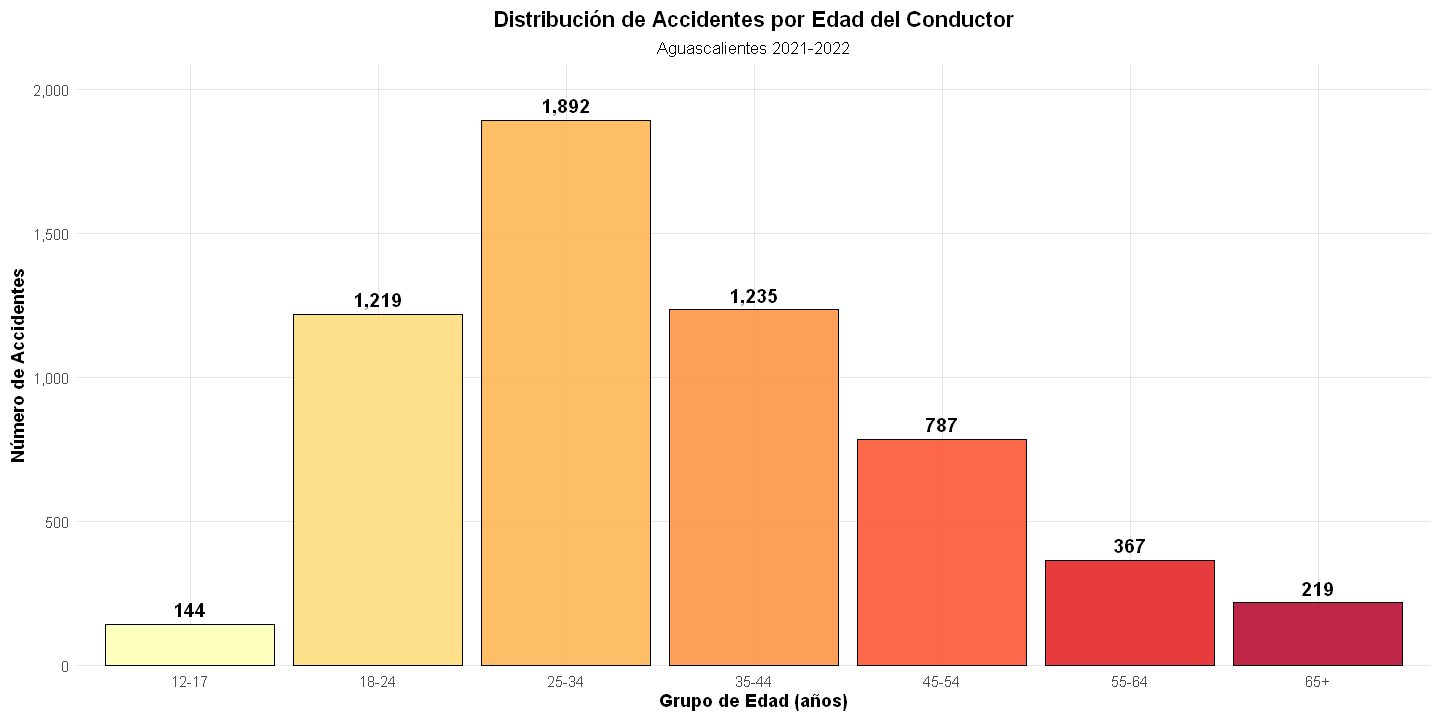

In [57]:
# Preparar datos
edad_grupos <- datos_completos %>%
  filter(EDAD >= 12 & EDAD < 99) %>%
  mutate(
    grupo_edad = cut(EDAD,
                     breaks = c(12, 18, 25, 35, 45, 55, 65, 100),
                     labels = c(
                                "12-17", "18-24", "25-34", "35-44",
                                "45-54", "55-64", "65+"),
                     right = FALSE)
  ) %>%
  count(grupo_edad) %>%
  filter(!is.na(grupo_edad))

# Crear gráfico
options(repr.plot.width = 12, repr.plot.height = 6)

ggplot(edad_grupos, aes(x = grupo_edad, y = n, fill = grupo_edad)) +
  geom_col(alpha = 0.85, color = "black", linewidth = 0.5) +
  geom_text(aes(label = comma(n)), vjust = -0.5,
            fontface = "bold", size = 4) +
  scale_fill_brewer(palette = "YlOrRd") +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.1))) +
  labs(title = "Distribución de Accidentes por Edad del Conductor",
       subtitle = "Aguascalientes 2021-2022",
       x = "Grupo de Edad (años)",
       y = "Número de Accidentes") +
  theme_accidentes() +
  theme(legend.position = "none")

**Interpretación:**

La distribución de accidentes por edad del conductor en el estado de Aguascalientes muestra una clara concentración en los grupos de adultos jóvenes. El grupo de 25–34 años registra la mayor cantidad de accidentes (1,892), seguido por los grupos de 35–44 años (1,235) y 18–24 años (1,219).

A partir de los 45 años se observa una disminución progresiva en la cantidad de accidentes, siendo los grupos de 55–64 y 65+ los que presentan menores frecuencias. El grupo de 12–17 años también presenta un número reducido en comparación con los grupos de adultos jóvenes.

Este patrón sugiere que los conductores jóvenes y adultos en edad productiva concentran la mayor participación en accidentes, posiblemente debido a mayor exposición al tráfico, mayor frecuencia de conducción y patrones de movilidad más intensivos.

**Hallazgos clave:**

- El grupo de 25–34 años concentra la mayor cantidad de accidentes.
- Los conductores entre 18 y 44 años representan la mayor proporción total de accidentes.
- A partir de los 45 años se observa una tendencia descendente en la frecuencia.
- Los grupos de 55+ presentan las cifras más bajas.
- Los adultos jóvenes constituyen el principal grupo de riesgo en términos de frecuencia de accidentes.

### Gráfico 15: Análisis por Género del Conductor

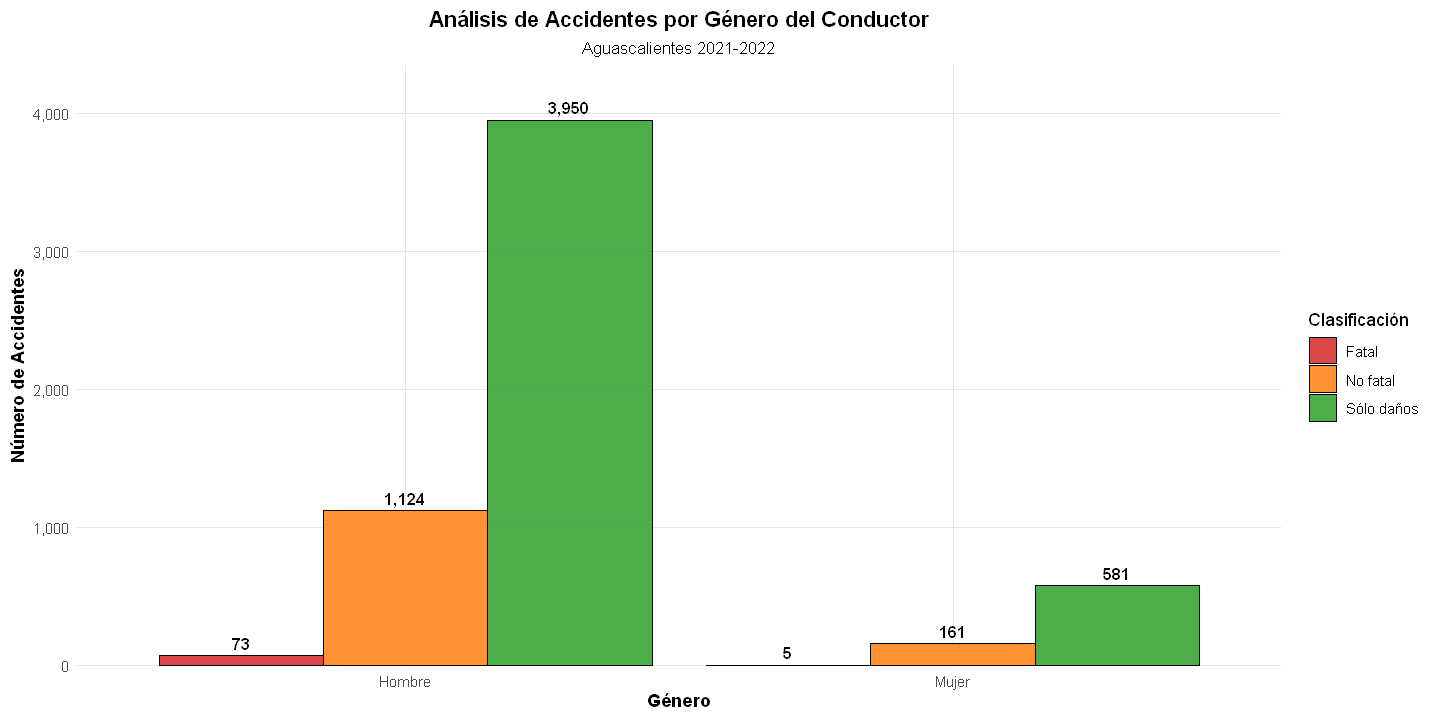

In [59]:
# Preparar datos
genero_severidad <- datos_completos %>%
  filter(sexo_conductor %in% c("Hombre", "Mujer"),
         !is.na(clase_nombre)) %>%
  group_by(sexo_conductor, clase_nombre) %>%
  summarise(n = n(), .groups = "drop")

# Crear gráfico
options(repr.plot.width = 12, repr.plot.height = 6)

ggplot(genero_severidad, aes(x = sexo_conductor, y = n, fill = clase_nombre)) +
  geom_col(position = "dodge", alpha = 0.85, color = "black", linewidth = 0.5) +
  geom_text(aes(label = comma(n)),
            position = position_dodge(width = 0.9),
            vjust = -0.5, fontface = "bold", size = 3.5) +
  scale_fill_manual(values = c("Fatal" = "#d62728",
                               "No fatal" = "#ff7f0e",
                               "Sólo daños" = "#2ca02c"),
                    name = "Clasificación") +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.1))) +
  labs(title = "Análisis de Accidentes por Género del Conductor",
       subtitle = "Aguascalientes 2021-2022",
       x = "Género",
       y = "Número de Accidentes") +
  theme_accidentes()

**Interpretación:**

El análisis de accidentes por género del conductor en el estado de Aguascalientes muestra una participación considerablemente mayor de hombres en todas las categorías de severidad.

Los hombres concentran la mayoría de los accidentes fatales (73), no fatales (1,124) y de sólo daños (3,950). En comparación, las mujeres registran 5 accidentes fatales, 161 no fatales y 581 de sólo daños. Esta diferencia puede estar asociada a una mayor exposición al manejo por parte de los hombres, mayor frecuencia de conducción o patrones de movilidad distintos.

En términos proporcionales, aunque ambos géneros presentan mayor concentración en la categoría “Sólo daños”, la magnitud absoluta de casos es significativamente superior en conductores hombres.

**Hallazgos clave:**

- Los hombres concentran la gran mayoría de los accidentes en todas las categorías.
- La mayor diferencia se observa en accidentes de “Sólo daños”.
- Los accidentes fatales son considerablemente más frecuentes en hombres (73 vs 5).
- Tanto en hombres como en mujeres, la categoría predominante es “Sólo daños”.
- La brecha de participación sugiere diferencias en exposición o comportamiento al conducir.

---

## Conclusiones generales

El análisis integral de los accidentes de tránsito en el estado de Aguascalientes durante 2021 y 2022 permite identificar patrones temporales claros, factores de riesgo predominantes y grupos poblacionales con mayor vulnerabilidad. Aunque el incremento total de accidentes entre ambos años fue moderado, se observan señales importantes que orientan la toma de decisiones en materia de seguridad vial.

### Patrones Temporales

- Los meses con mayor incidencia se concentran en mayo, octubre y diciembre.
- Octubre es un mes consistentemente alto en ambos años.
- Los fines de semana (sábado y domingo) presentan la mayor frecuencia de accidentes.
- Los horarios más críticos son la medianoche (00:00) y el bloque nocturno entre 19:00 y 23:00 horas.
- Entre 2021 y 2022 hubo un incremento general aproximado del 3.6%, con mayor crecimiento en el segundo semestre de 2022.

### Severidad y Consecuencias

- La mayoría de los accidentes corresponden a la categoría “Sólo daños”.
- Los accidentes fatales representan una proporción pequeña del total, pero con impacto humano significativo.
- En 2022 disminuyeron ligeramente las muertes, pero aumentaron las personas heridas.
- Los tipos de accidente más letales incluyen colisión con objeto fijo, atropellamiento y colisión con motocicleta.

### Factores de Riesgo Principales

- El factor humano (conductor) es responsable de más del 96% de los accidentes.
- La presencia de aliento alcohólico aparece en una proporción reducida de casos; sin embargo, los horarios críticos coinciden con periodos de mayor riesgo potencial.
- El uso del cinturón de seguridad muestra un impacto protector evidente: no se registraron muertes cuando se reportó su uso.
- Las colisiones vehiculares representan el tipo de accidente más frecuente.

### Grupos Vulnerables

- Los conductores de 18 a 44 años concentran la mayor cantidad de accidentes, especialmente el grupo de 25–34 años.
- Los hombres presentan una participación considerablemente mayor en todas las categorías de severidad.
- Los accidentes con motocicleta presentan mayor proporción de lesiones y una tasa de fatalidad superior en comparación con los accidentes sin motocicleta.
- La gran mayoría de los accidentes ocurre en zonas urbanas.

### Mensaje Principal

Los datos evidencian que los accidentes de tránsito en Aguascalientes están fuertemente asociados al comportamiento del conductor, con patrones temporales bien definidos que concentran el riesgo en fines de semana y horarios nocturnos. Aunque la mayoría de los eventos resultan en daños materiales, el impacto humano en términos de lesiones y muertes sigue siendo significativo.

El grupo más afectado corresponde a adultos jóvenes, particularmente hombres y motociclistas, lo que sugiere que las estrategias de intervención deben enfocarse prioritariamente en estos sectores. Asimismo, el uso del cinturón de seguridad demuestra ser una medida altamente efectiva para reducir consecuencias fatales, lo que refuerza la importancia de su promoción y vigilancia.

---

## Recomendaciones

### 1. Campañas de Concientización

- Campaña intensiva sobre conducción responsable dirigida a hombres de 18–44 años.
- Promoción del uso obligatorio del cinturón de seguridad con enfoque en reducción de mortalidad.
- Campañas específicas para motociclistas sobre uso de equipo de protección y conducción defensiva.
- Mensajes preventivos focalizados en fines de semana y horarios nocturnos.

### 2. Reforzamiento de Vigilancia

- Incrementar operativos de tránsito en sábados y domingos.
- Mayor presencia de patrullaje entre 19:00 y 02:00 horas.
- Implementar controles de alcoholimetría en horarios críticos.
- Supervisión específica en zonas urbanas de alta densidad vehicular.

### 3. Mejoras en Infraestructura

- Señalización reforzada en puntos con alta incidencia de colisión contra objeto fijo.
- Iluminación mejorada en zonas urbanas con alta frecuencia nocturna.
- Adecuación de carriles y espacios seguros para motociclistas.
- Intervenciones en cruces urbanos con alta incidencia de atropellamientos.

### 4. Educación Vial

- Programas educativos dirigidos a conductores jóvenes (18–34 años).
- Talleres obligatorios de conducción segura para motociclistas.
- Integración de módulos de cultura vial en instituciones educativas.
- Capacitación periódica sobre conducción preventiva y manejo de riesgos.

### 5. Políticas Públicas

- Revisión de límites de velocidad en zonas urbanas con alta concentración de accidentes.
- Fortalecimiento de sanciones por no uso de cinturón de seguridad.
- Incentivos para certificación de cursos de conducción segura.
- Implementación de sistemas de monitoreo y análisis continuo de datos de accidentalidad.

### Priorización

Las acciones que deberían implementarse primero son:

1. **Reforzamiento de vigilancia en fines de semana y horarios nocturnos**, debido a la alta concentración temporal del riesgo y su rápida factibilidad.
2. **Campañas de promoción del uso del cinturón de seguridad**, por su bajo costo y alto impacto en reducción de mortalidad.
3. **Intervenciones focalizadas en motociclistas**, dado su mayor nivel de severidad en accidentes.
4. **Programas educativos para adultos jóvenes**, por atender al grupo con mayor frecuencia de participación.

Estas medidas priorizan intervenciones de alto impacto, factibilidad operativa inmediata y buena relación costo-efectividad.

---

## Referencias

1. Instituto Nacional de Estadística y Geografía (INEGI). (2021-2022). *Accidentes de tránsito terrestre en zonas urbanas y suburbanas*. Subsistema de Información Económica - Registros Administrativos. Recuperado de https://www.inegi.org.mx/datosabiertos/

2. R Graphics Cookbook https://r-graphics.org/

3. R Charts https://r-charts.com/ggplot2/

4. Wickham, H., Navarro, D., & Pedersen, T. L. (2016). *ggplot2: Elegant Graphics for Data Analysis*. Springer-Verlag New York. https://ggplot2.tidyverse.org/

5. Wickham, H., François, R., Henry, L., & Müller, K. (2023). *dplyr: A Grammar of Data Manipulation*. https://dplyr.tidyverse.org/

6. [Repositorio de GitHub con Jupiter Notebook de la Practica.](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%202/3%20-%20Lenguajes%20de%20ciencia%20de%20datos%20intermedio/Practica%206.1/Visualización%20de%20datos%20con%20ggplot2.ipynb)